# **Purchasing Intention Online Shoppers**

---

# **STAGE 1 - EDA (Exploratory Data Analysis)**

# **0. Load Dataset**
---

In [43]:
# mengimpor library

import pandas as pd 
import numpy as np                     
import seaborn as sns                  
import matplotlib.pyplot as plt       
from matplotlib import rcParams
%matplotlib inline
import warnings                

warnings.filterwarnings("ignore")

In [44]:
# read dataset
url = 'https://drive.google.com/file/d/1UJ07j4gSGHTDpw53wO3L2y4eoXesZbMN/view?usp=sharing'
file_id = url.split('/')[-2]
dwn_url = 'https://drive.google.com/uc?id=' + file_id

df = pd.read_csv(dwn_url)

# **1. Descriptive Statistics**
---

### **A ) Tipe Data**

In [45]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [46]:
# quantity rows and feature
df.shape

(12330, 18)

Based on the data exploration results, the dataset contains no missing values. It consists of 12,330 records (rows) and 18 features (columns)

### **B ) Missing Value**

In [47]:

df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

The dataset contains no missing values

### **C ) Data Duplikat**

In [48]:

df.duplicated().any()

np.True_

In [49]:
df.duplicated().sum()

np.int64(125)

The dataset contains 125 duplicate records.

### **D ) Unique Value**

In [50]:
#Analyzing the unique values in each feature.
for col in df.columns:
    print(f'{col} has {df[col].nunique()} unique values ({df[col].dtype}):')
    print(f'{col} values: {df[col].unique()}')

Administrative has 27 unique values (int64):
Administrative values: [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]
Administrative_Duration has 3335 unique values (float64):
Administrative_Duration values: [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]
Informational has 17 unique values (int64):
Informational values: [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]
Informational_Duration has 1258 unique values (float64):
Informational_Duration values: [  0.   120.    16.   ... 547.75 368.25 211.25]
ProductRelated has 311 unique values (int64):
ProductRelated values: [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  7

- Two months are missing from the dataset: January and April.
- The VisitorType feature includes an Other category.
- Categorical features such as OperatingSystems, Browser, Region, and TrafficType have already been encoded.


### **E ) Statistical Summary**

In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


- The majority of numerical features have a mean lower than the median (Mean < Median), indicating that their distributions are positively skewed.
- Website traffic-related features, including Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, and PageValues, contain a large number of zero values, indicating that most observations have no activity recorded for these features.

In [52]:
# Descriptive Statistics of Categorical Features
df_cat1 = df.select_dtypes(['object','bool']).describe().T
df_cat1['% freq'] = (df_cat1['freq']/df_cat1['count']*100)
df_cat1

,count,unique,top,freq,% freq
Month,12330,10,May,3364,27.283049
VisitorType,12330,3,Returning_Visitor,10551,85.571776
Weekend,12330,2,False,9462,76.739659
Revenue,12330,2,False,10422,84.525547


In [53]:
df_cat2 = df[['OperatingSystems', 'Browser', 'Region', 'TrafficType']].astype('object').describe().T
df_cat2['% freq'] = (df_cat2['freq']/df_cat2['count']*100)
df_cat2

,count,unique,top,freq,% freq
OperatingSystems,12330,8,2,6601,53.536091
Browser,12330,13,2,7961,64.566099
Region,12330,9,1,4780,38.767234
TrafficType,12330,20,2,3913,31.735604


- The highest number of website visitors was recorded in May
- Approximately 85% of the visitors were Returning Visitors.
- About 84% of website visitors did not make a purchase.
- Most visitors came from Region 1 and accessed the website using Operating System 2, Browser 2, and Traffic Type 2.


### **F ) Target Feature Description**

In [54]:
# Distribution of True and False Values in the Revenue Feature
revenue_col = df['Revenue'].value_counts().reset_index()
revenue_col.columns = ['Revenue', 'count']
revenue_col['%'] = (revenue_col['count']/revenue_col['count'].sum()*100).round(2)
revenue_col

,Revenue,count,%
0,False,10422,84.53
1,True,1908,15.47


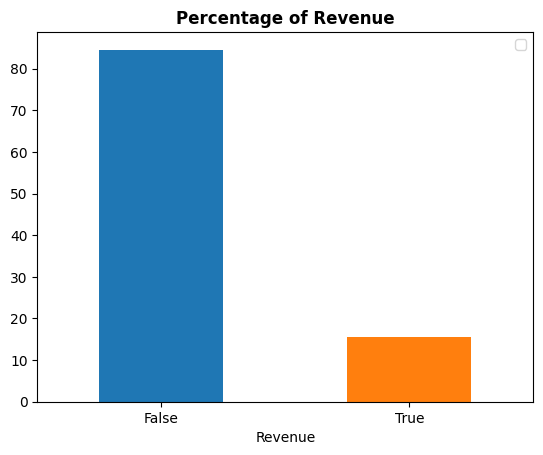

In [55]:
# creating visualization
x = revenue_col.plot(kind='bar', x='Revenue', y='%', color=sns.color_palette('tab10'))
plt.title('Percentage of Revenue', fontweight='bold')
plt.xticks(rotation=360)
plt.legend('')

# **2. Univariate Analysis**
---

### **A ) Data Type Classification**

In [56]:
# Categorical Data
cats = df.loc[:, (df.dtypes == 'object') | (df.dtypes == 'bool')].columns.tolist()
print(cats)
print('Counts :', len(cats))

['Month', 'VisitorType', 'Weekend', 'Revenue']
Counts : 4


In [57]:
# Numerical Data
nums = df.loc[:, (df.dtypes == 'int64') | (df.dtypes == float)].columns.tolist()
print(nums)
print('Counts :', len(nums))

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Counts : 14


In [58]:
# Split data set
nums = nums.copy()
cats = cats.copy()

### **B ) Numerical Features**

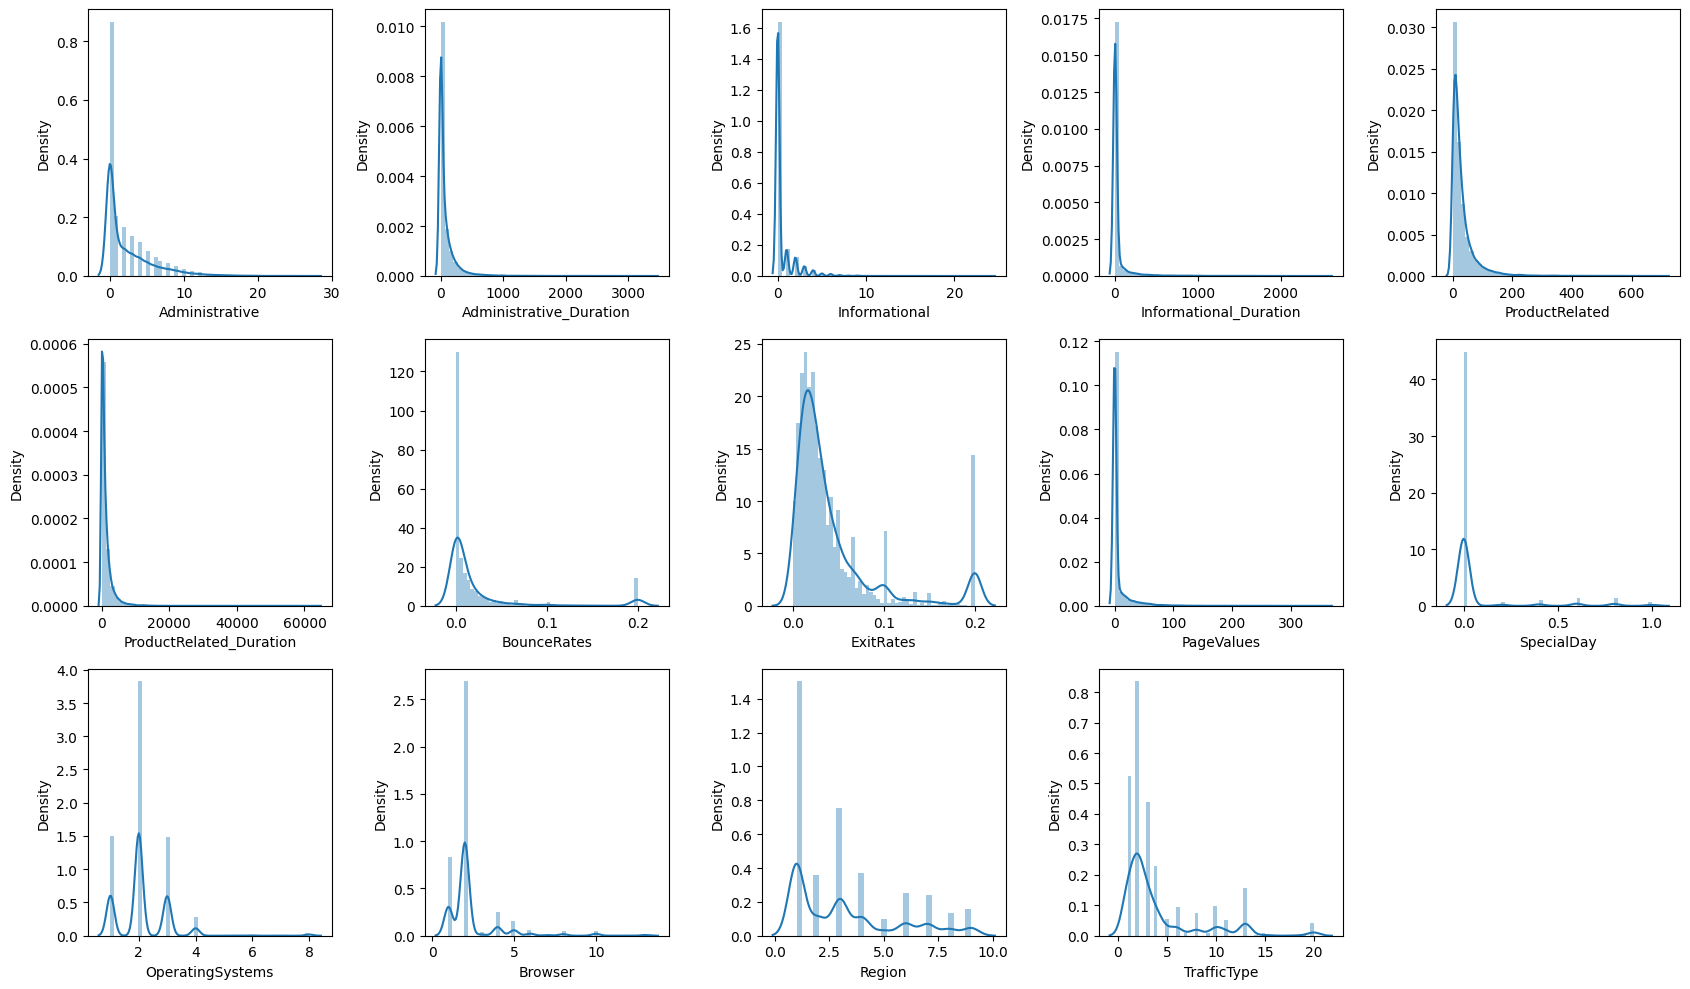

In [59]:
# Distribution and Skewness Analysis of Numerical Features
plt.figure(figsize=(17, 10))
for i in range(0, len(nums)):
    plt.subplot(3, 5, i+1)
    sns.distplot(df[nums[i]])
    plt.tight_layout()

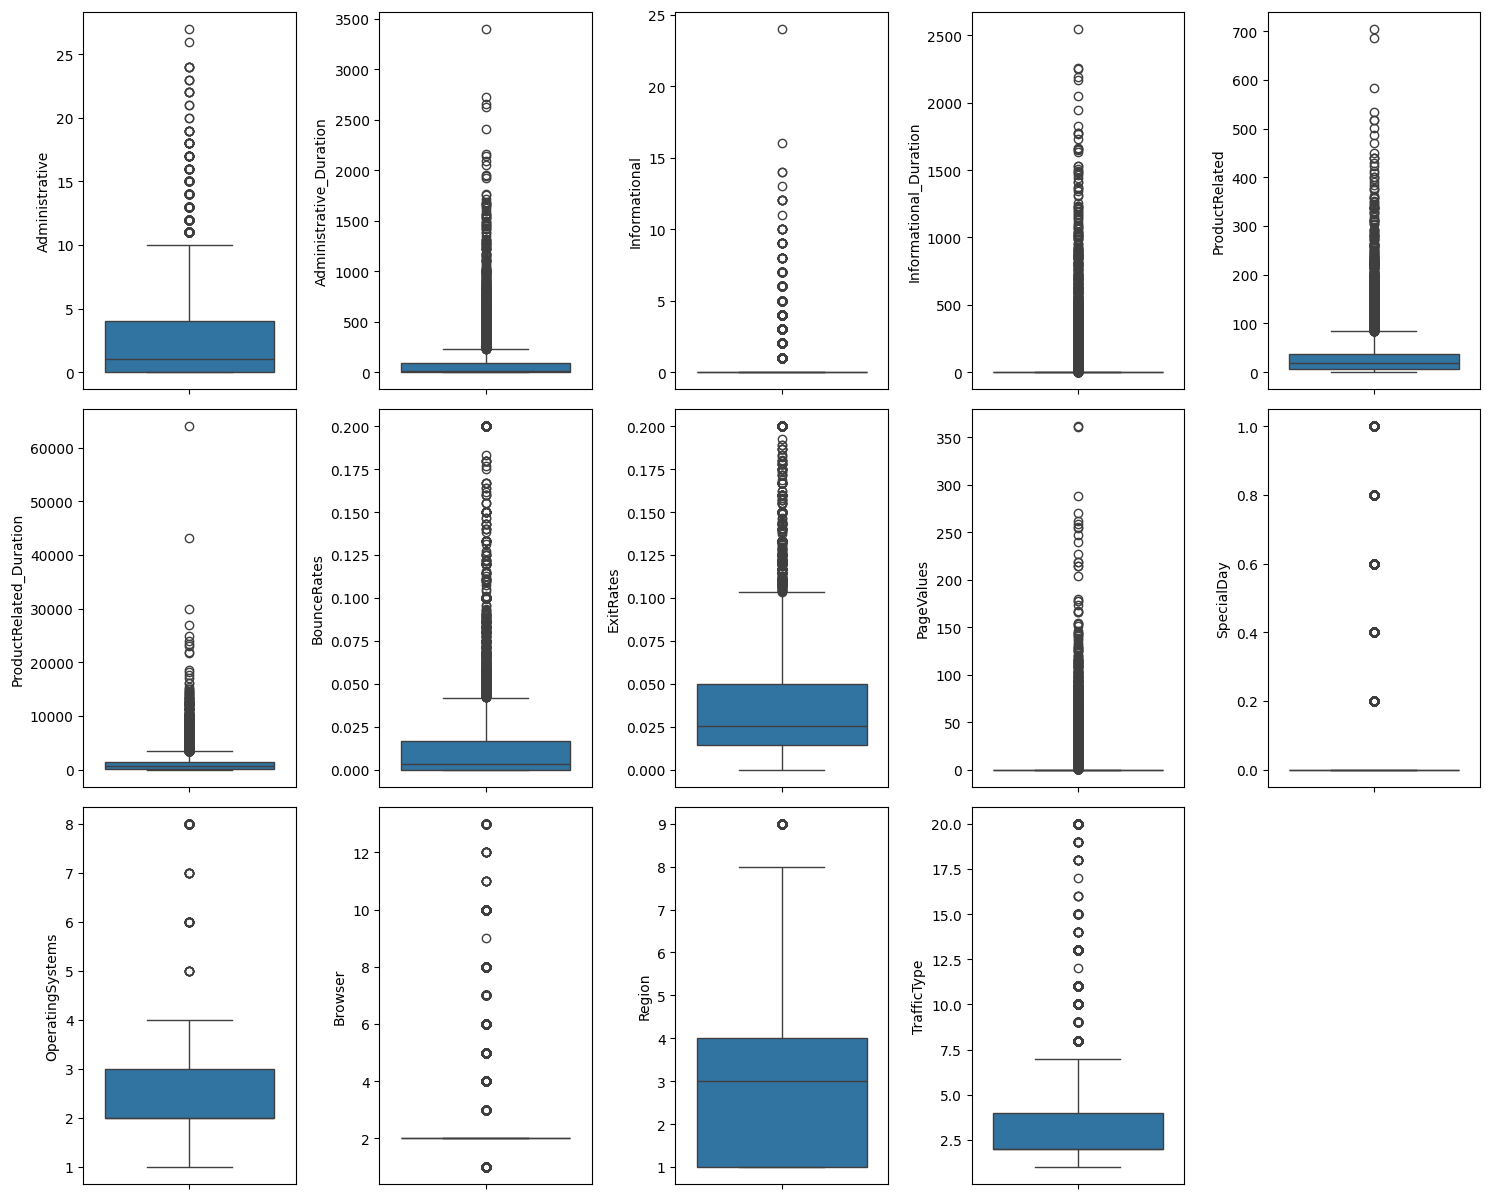

In [60]:
# Distribution and Outlier Analysis Using Boxplots
plt.figure(figsize=(15, 20))
for i in range(0, len(nums)):
    plt.subplot(5, 5, i+1)
    sns.boxplot(y=df[nums[i]], orient='v')
    plt.tight_layout()

- Most numerical features exhibit positively skewed distributions with long right tails.
- Consequently, boxplot analysis reveals the presence of potential outliers in many numerical features.

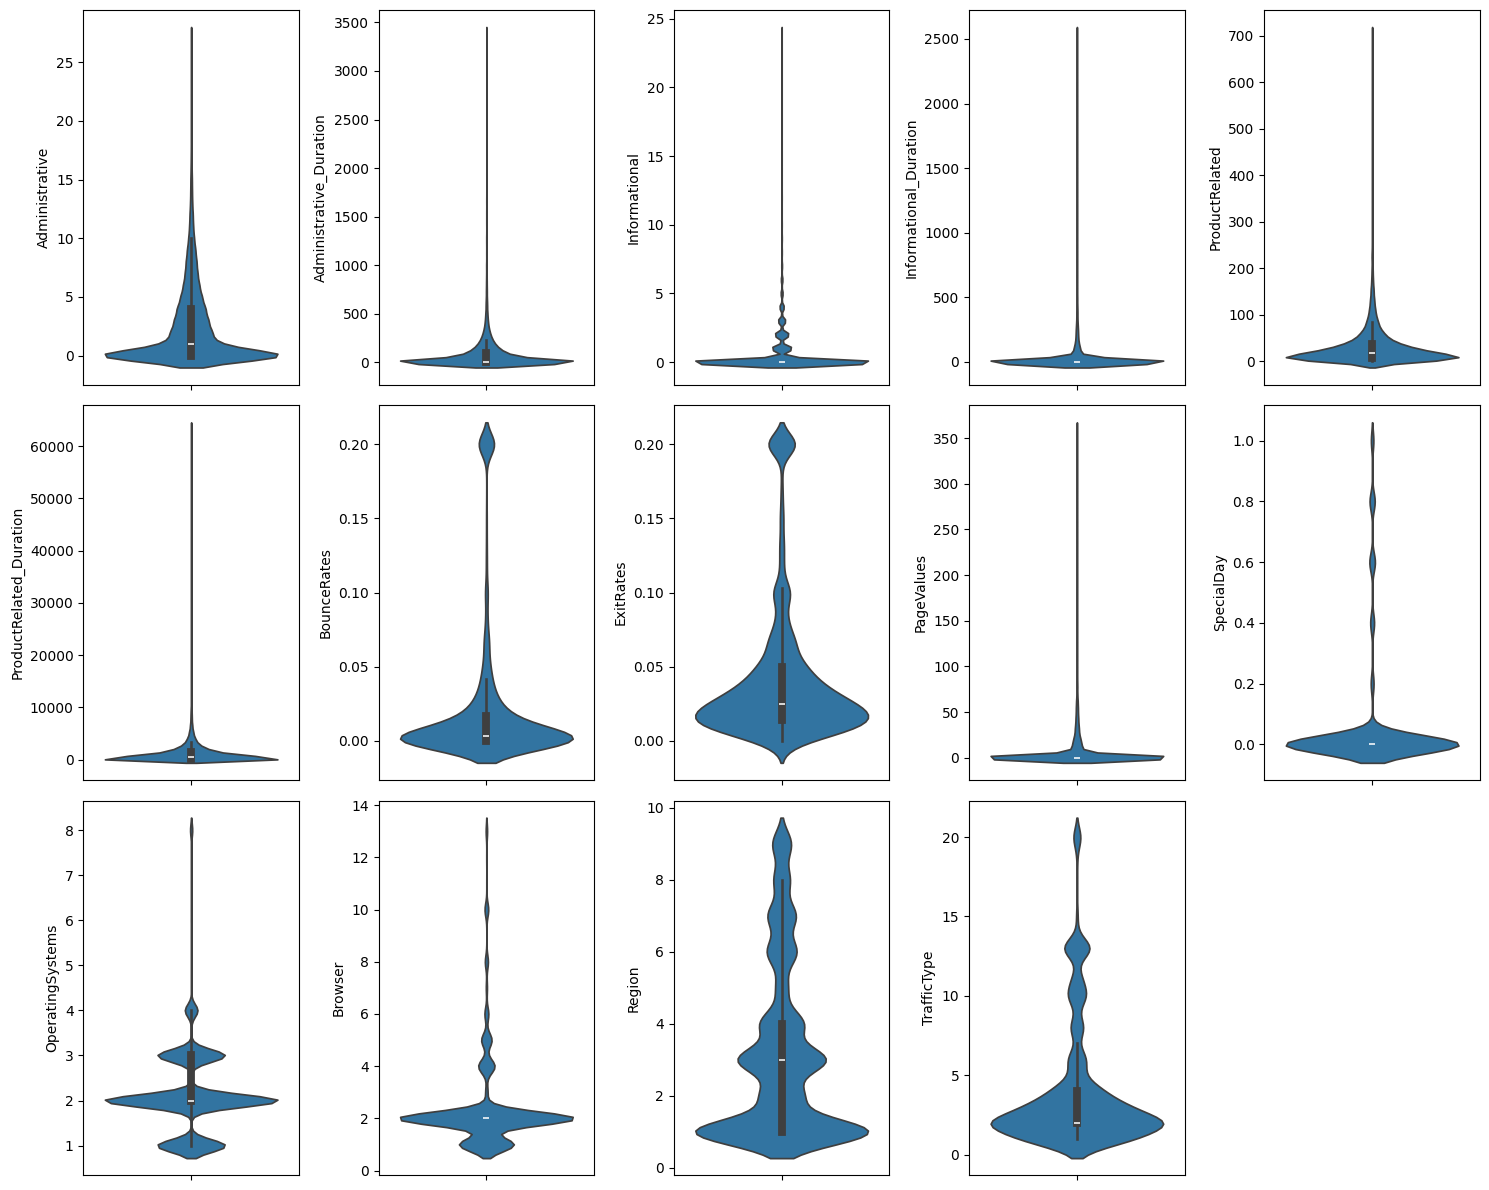

In [61]:
# Distribution Analysis Using Violin Plots
plt.figure(figsize=(15, 12))
for i in range(0, len(nums)):
    plt.subplot(3, 5, i+1)
    sns.violinplot(y = df[nums[i]], orient='v')
    plt.tight_layout()

The violin plots show that Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, PageValues, and SpecialDay are highly concentrated around the value of 0, indicating that most observations have little or no activity for these features.

### **C ) Categorical Features**

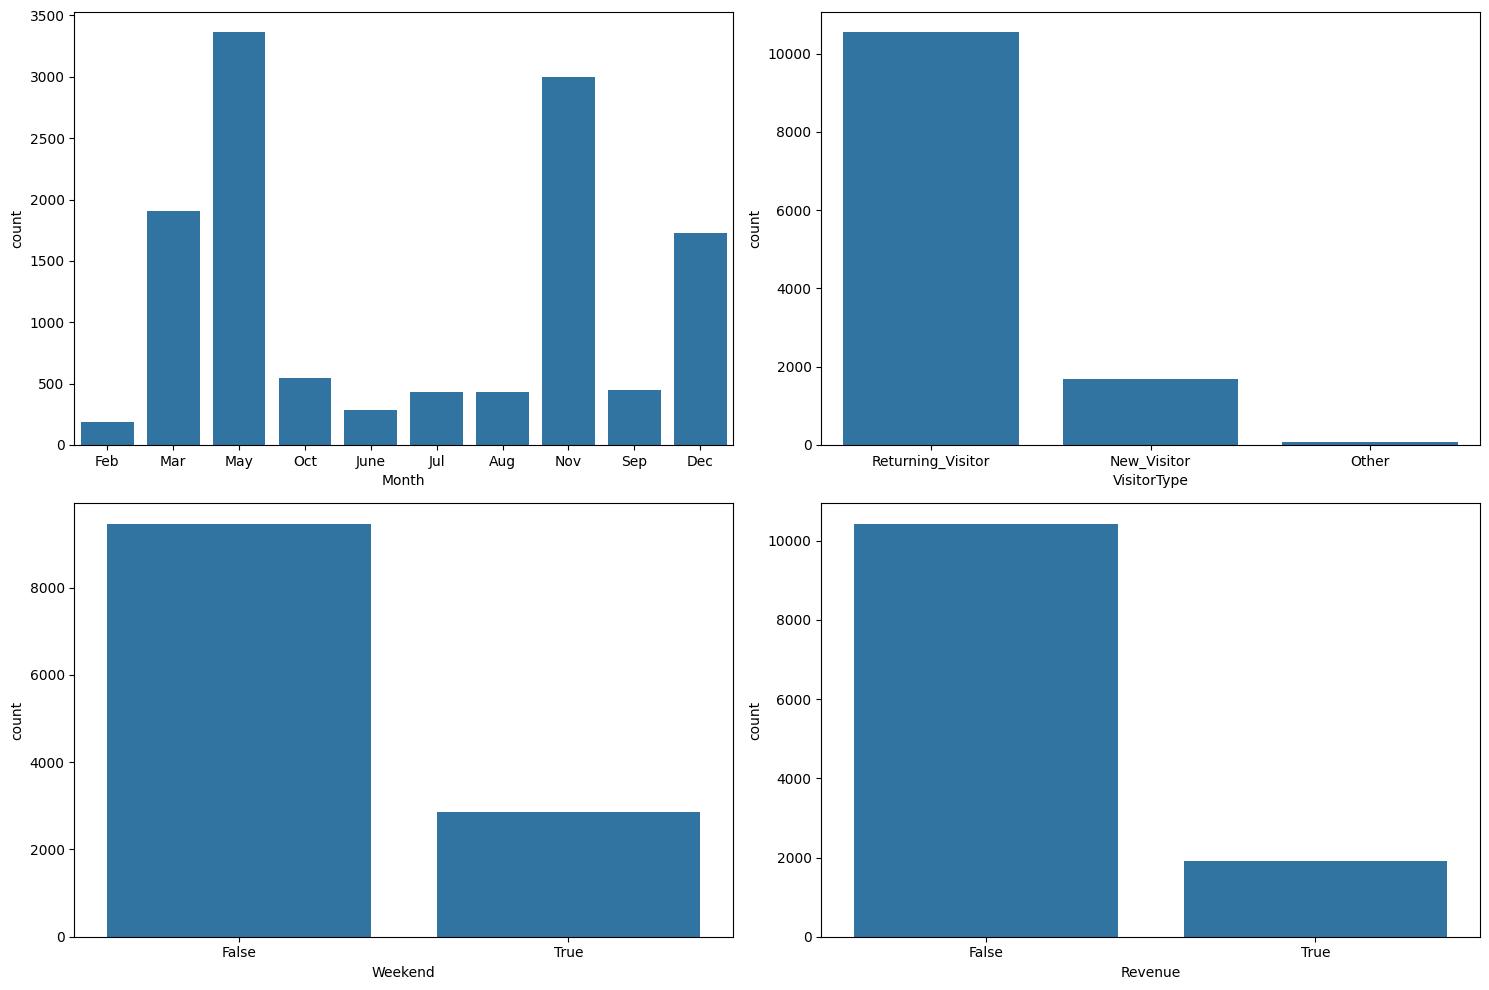

In [62]:
# Categorical Feature Distribution Using Count Plots
plt.figure(figsize=(15, 10))
features = cats
for i in range(0, len(features)):
  plt.subplot(2, 2, i+1)
  sns.countplot(x=df[features[i]], orient='v')
  plt.tight_layout()

# **3. Multivariate Analysis**
---

In [63]:
# Distinguishing Between Numerical and Categorical Features
nums = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
       'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Revenue']
cats = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weetond', 'Month', 'Revenue']

### **A ) Relationships Among Numerical Features**

In [64]:
# Relationship Between Numerical Features and the Target Variable
nums_and_revenue = df[nums]
nums_and_revenue['Revenue'] = df['Revenue']
nums_and_revenue.T

,0,1,2,3,4,5,6,7,8,9,...,12320,12321,12322,12323,12324,12325,12326,12327,12328,12329
Administrative,0,0,0,0,0,0,0,1,0,0,...,0,0,6,2,0,3,0,0,4,0
Administrative_Duration,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,76.25,64.75,0.0,145.0,0.0,0.0,75.0,0.0
Informational,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
Informational_Duration,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ProductRelated,1,2,1,2,10,19,1,0,2,3,...,8,6,22,44,16,53,5,6,15,3
ProductRelated_Duration,0.0,64.0,0.0,2.666667,627.5,154.216667,0.0,0.0,37.0,738.0,...,143.583333,0.0,1075.25,1157.97619,503.0,1783.791667,465.75,184.25,346.0,21.25
BounceRates,0.2,0.0,0.2,0.05,0.02,0.015789,0.2,0.2,0.0,0.0,...,0.014286,0.2,0.0,0.0,0.0,0.007143,0.0,0.083333,0.0,0.0
ExitRates,0.2,0.1,0.2,0.14,0.05,0.024561,0.2,0.2,0.1,0.022222,...,0.05,0.2,0.004167,0.013953,0.037647,0.029031,0.021333,0.086667,0.021053,0.066667
PageValues,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12.241717,0.0,0.0,0.0,0.0
SpecialDay,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.8,0.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Figure size 2000x2000 with 0 Axes>

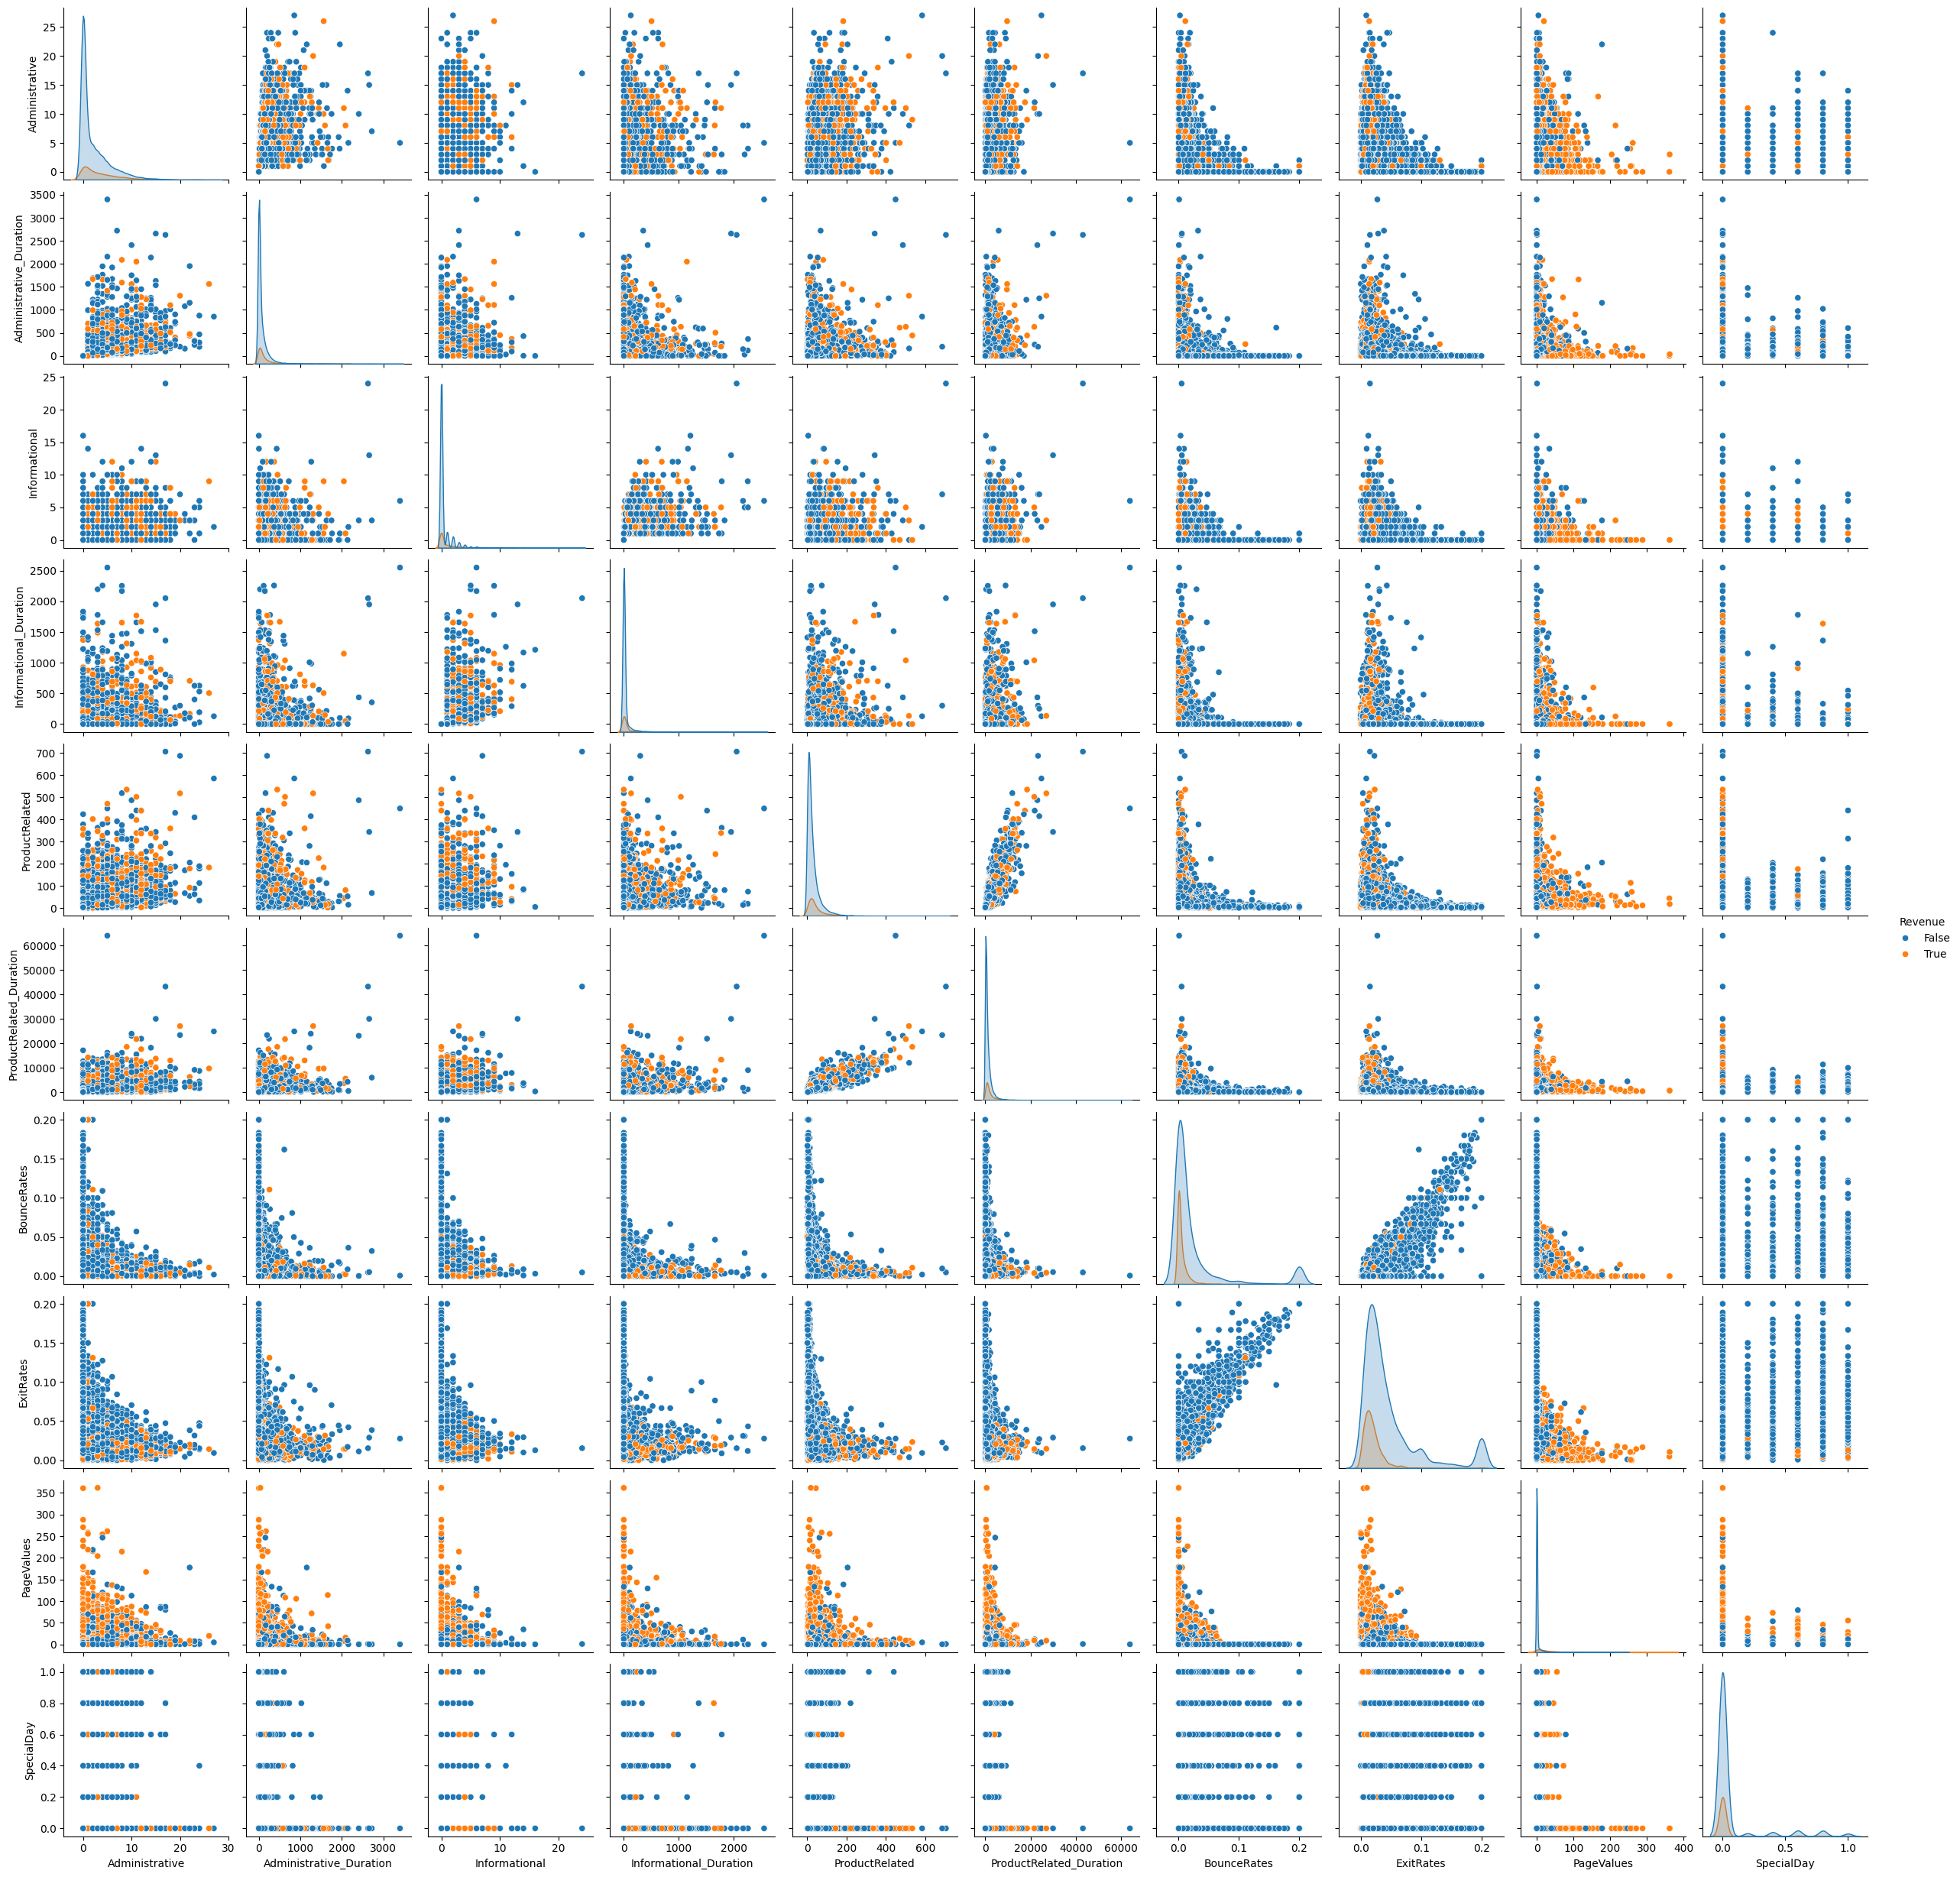

In [65]:
plt.figure(figsize = (20,20))
sns.pairplot(nums_and_revenue, hue = 'Revenue')

<Axes: >

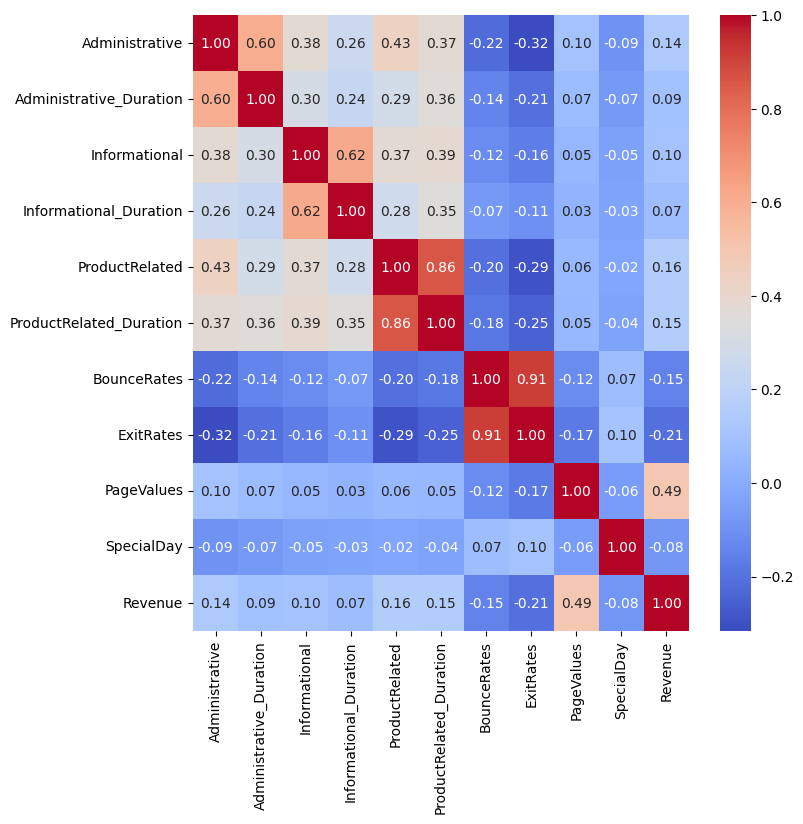

In [66]:
# Correlation Analysis Using a Heatmap
plt.figure(figsize = (8,8))
sns.heatmap(df[nums].corr(), cmap = 'coolwarm', annot = True, fmt = '.2f')

- ExitRates and BounceRates exhibit a strong positive correlation (correlation coefficient > 0.7), indicating potential multicollinearity. Since these features capture similar information, one of them may be removed during the data preprocessing stage.

- Several feature pairs also show relatively high correlations, suggesting potential redundancy. These include ProductRelated and ProductRelated_Duration, Administrative and Administrative_Duration, Informational and Informational_Duration, as well as BounceRates and ExitRates. During data preprocessing, one feature from each highly correlated pair may be retained to reduce redundancy and multicollinearity.

- The PageValues feature shows the strongest correlation with the target variable (Revenue), with a correlation coefficient of approximately 0.49. This suggests that PageValues may be an important predictor of purchase behavior.

- The scatter plots indicate that BounceRates, ExitRates, and PageValues exhibit logarithmic relationships with several other numerical features. For example, BounceRates and Informational_Duration display an inverse logarithmic relationship, where higher BounceRates are associated with lower Informational_Duration values. This suggests the presence of non-linear relationships that may be useful for feature engineering or model selection.

### **B ) Relationship Between Categorical and Numerical Features**

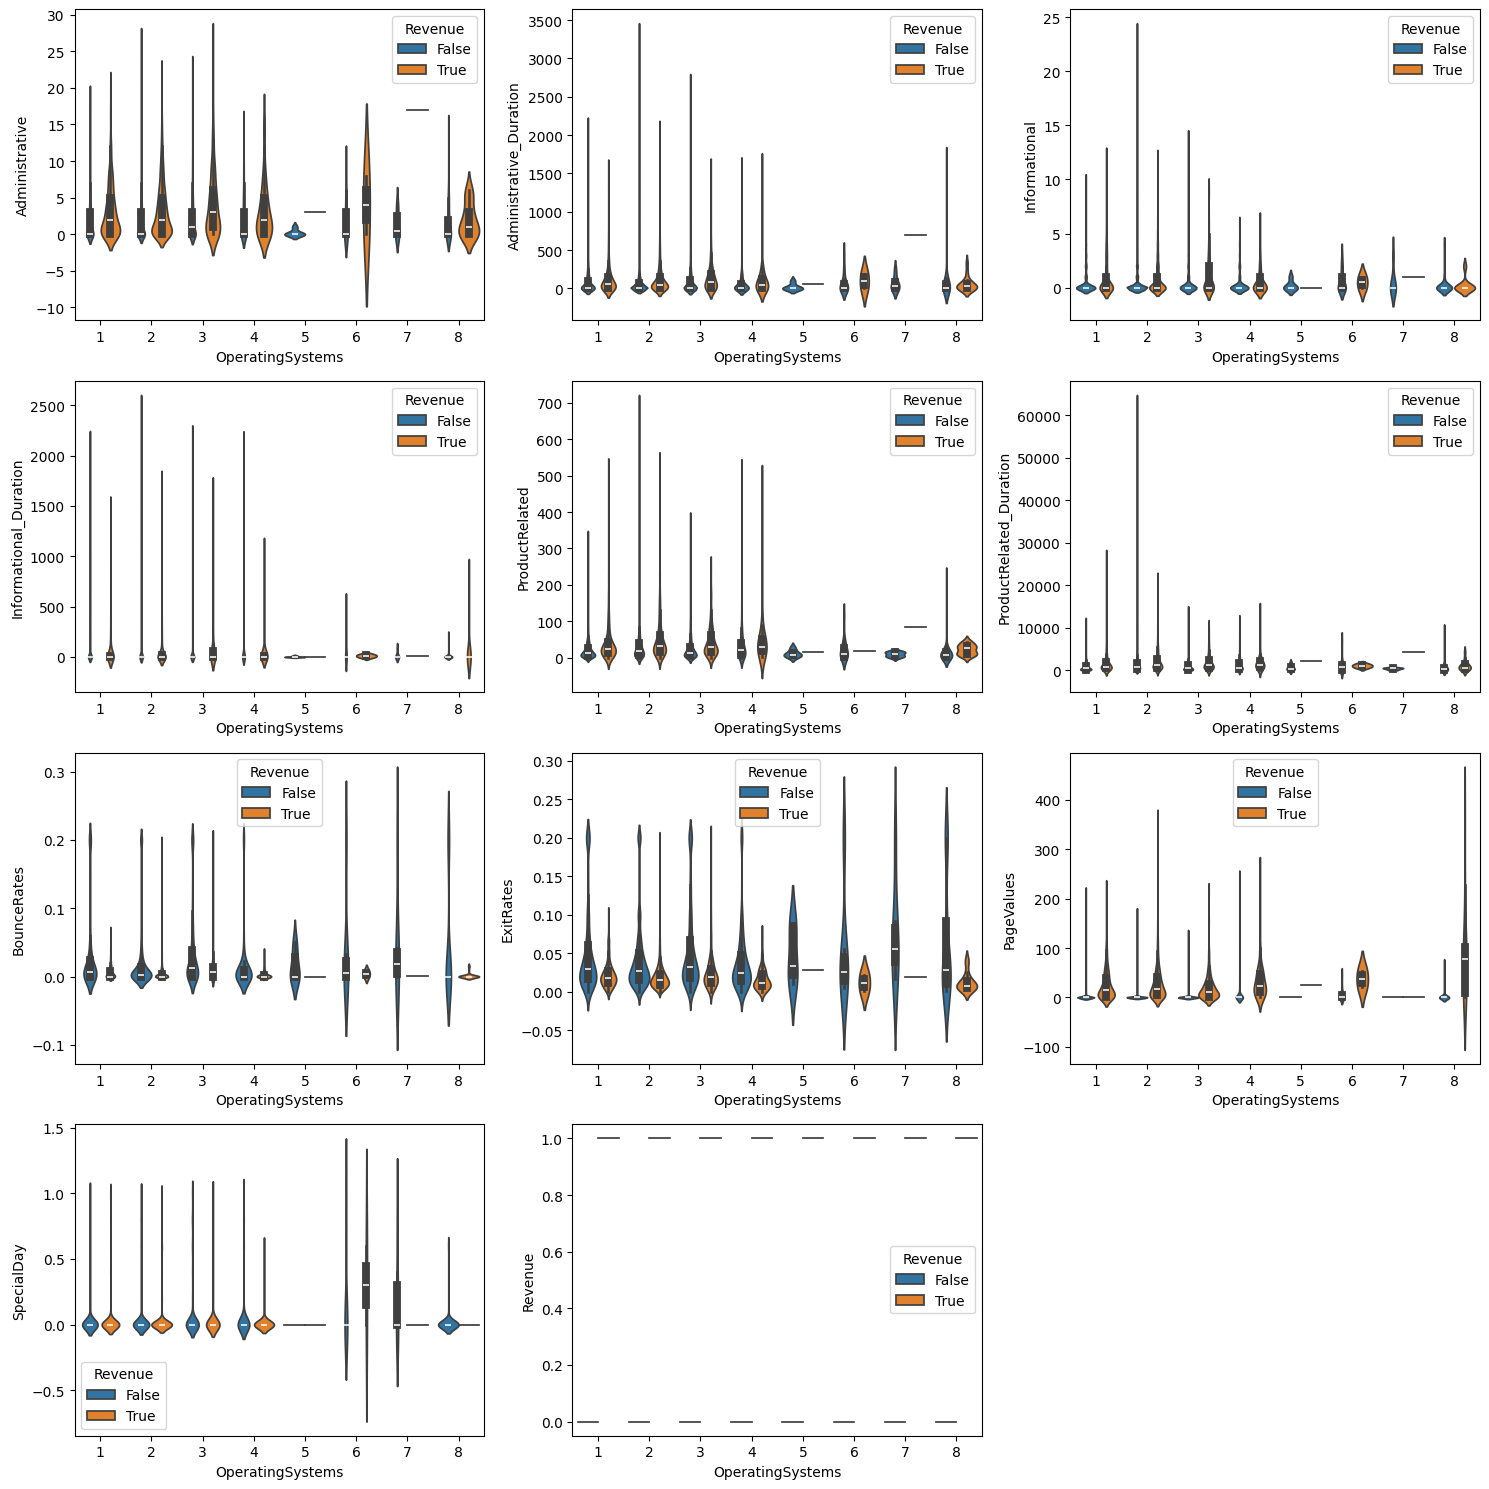

In [67]:
# Relationship between OperatingSystems and numerical features
fig = plt.figure(figsize=(15, 15))
for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(4, 3, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot(ax=ax,data=df,x='OperatingSystems',y=nums[i],hue='Revenue' )  # Draw the violin plot

    plt.tight_layout()

Only a small proportion of visitors used Operating Systems 5, 6, 7, and 8. However, these categories show relatively higher values for BounceRates, ExitRates, and SpecialDay. This observation is consistent with the negative correlations between these features and several other numerical variables identified in the correlation analysis.

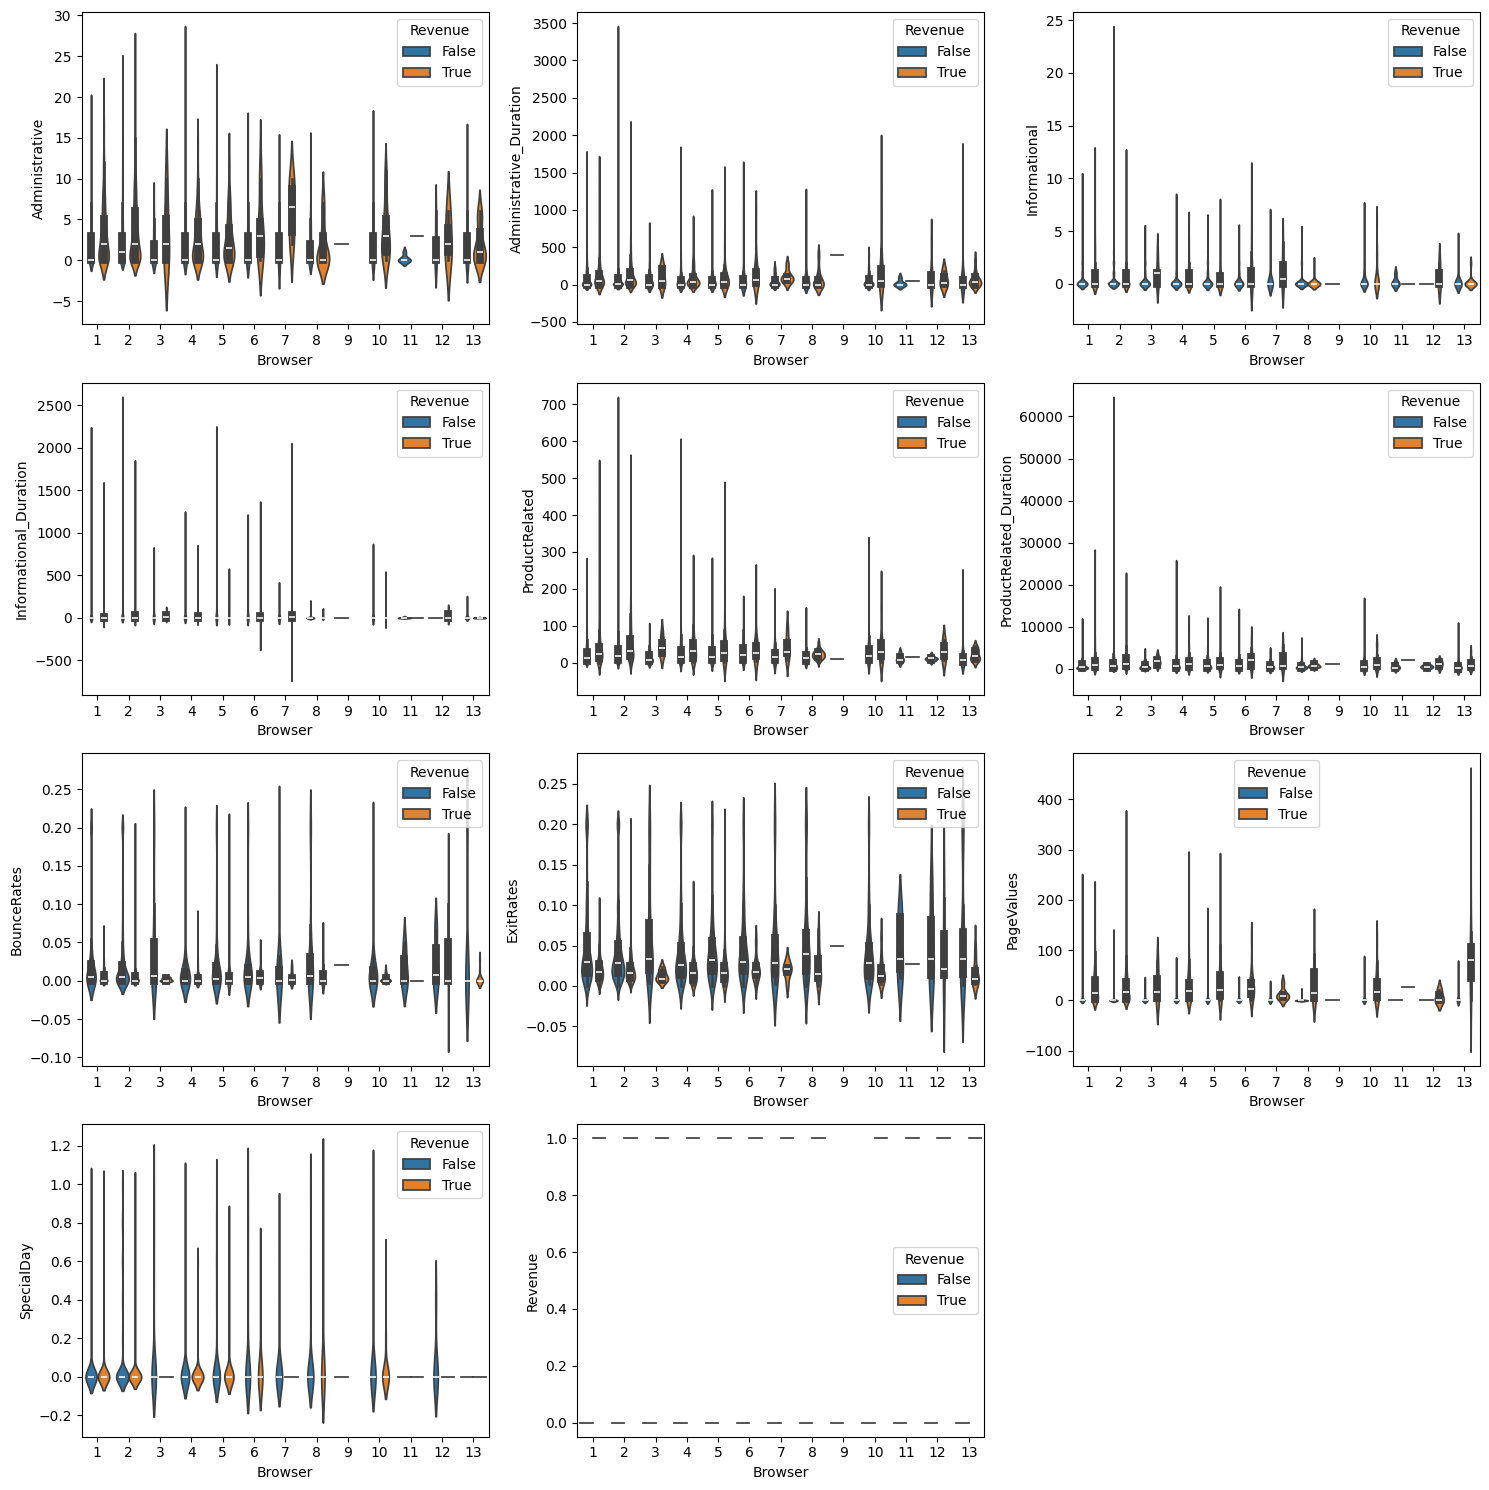

In [68]:
# Relationship between Browser and numerical features
fig = plt.figure(figsize=(15, 15))

for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(4, 3, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot(ax=ax, data=df, x='Browser',y=nums[i],hue='Revenue')  # Draw the violin plot

    plt.tight_layout()

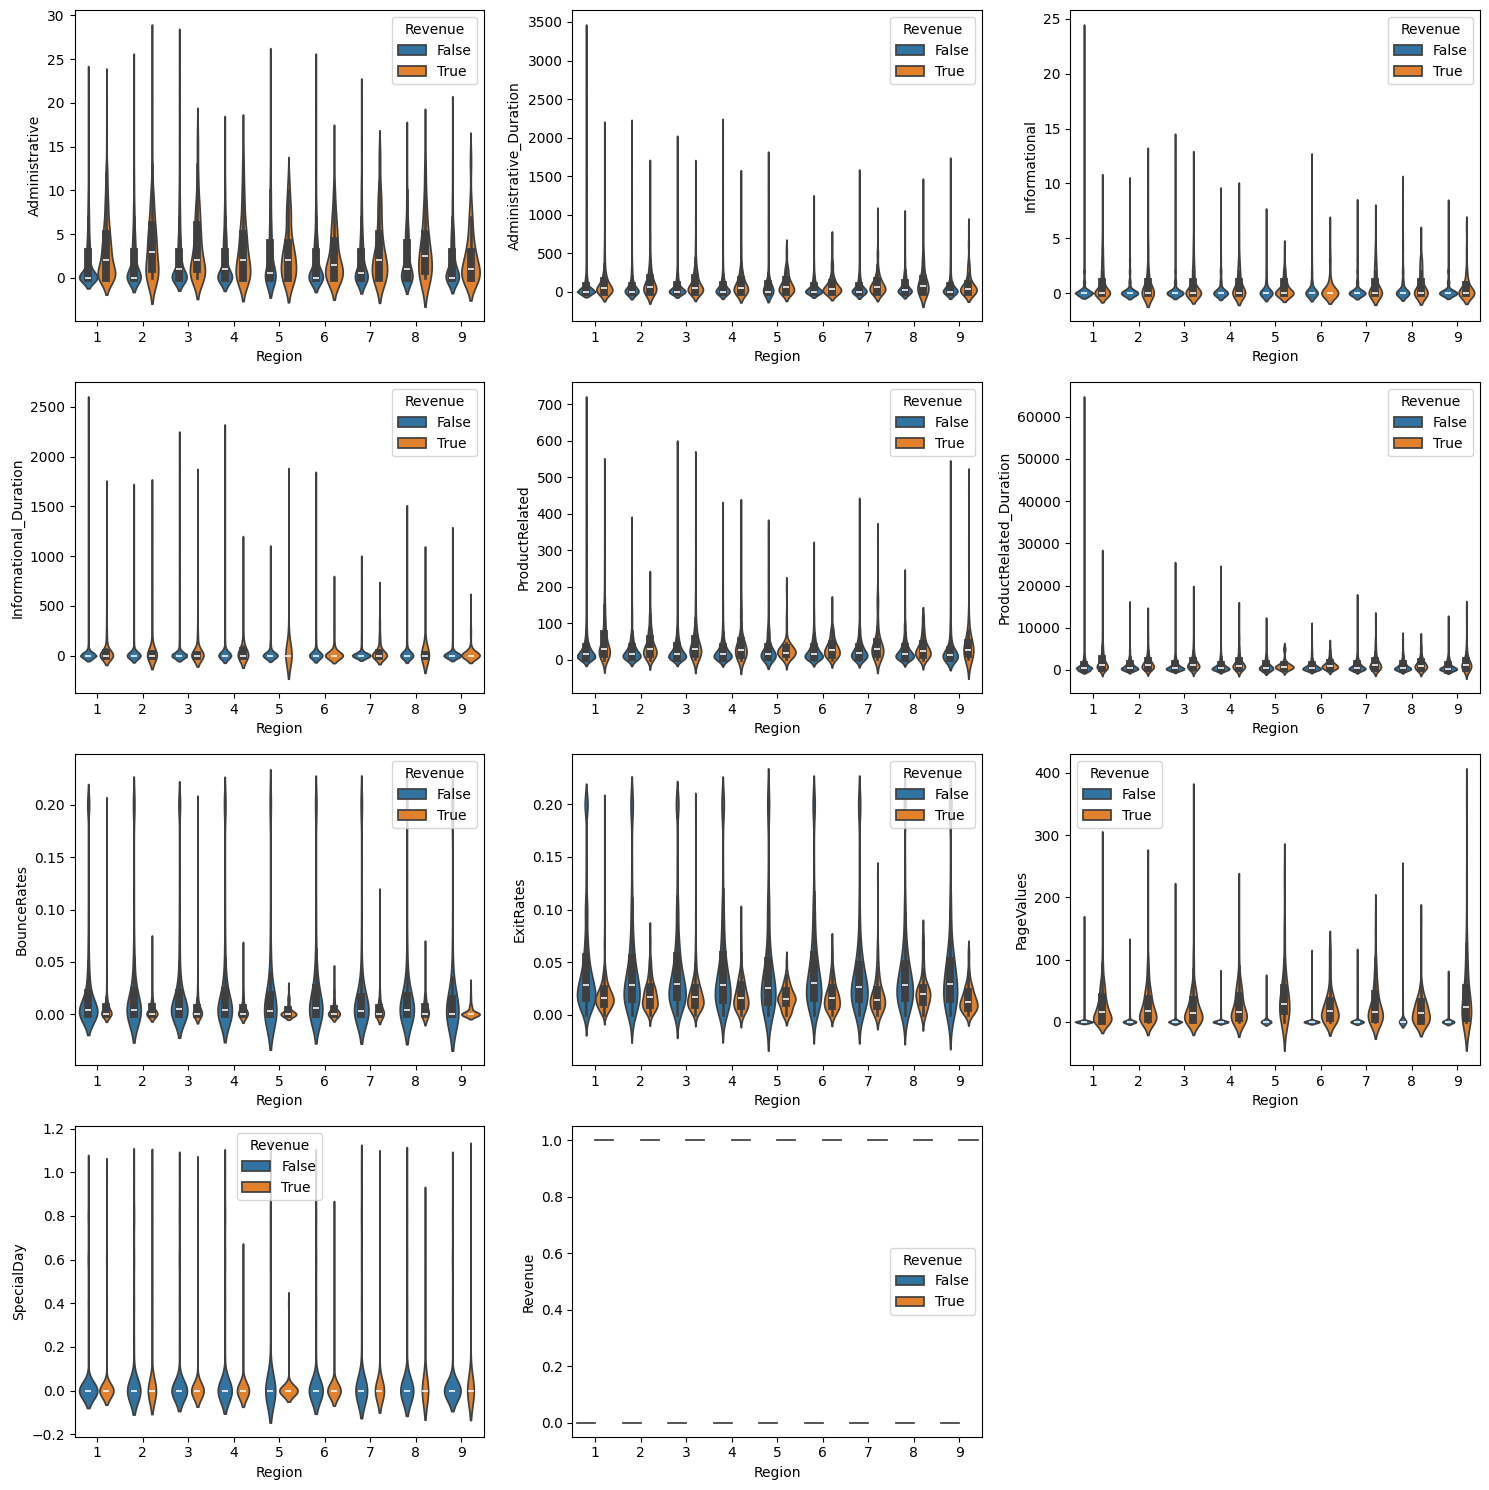

In [69]:
# Relationship between Region and numerical features
fig = plt.figure(figsize=(15, 15))

for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(4, 3, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot(ax=ax, data=df,x='Region',y=nums[i],hue='Revenue' )  # Draw the violin plot

    plt.tight_layout()

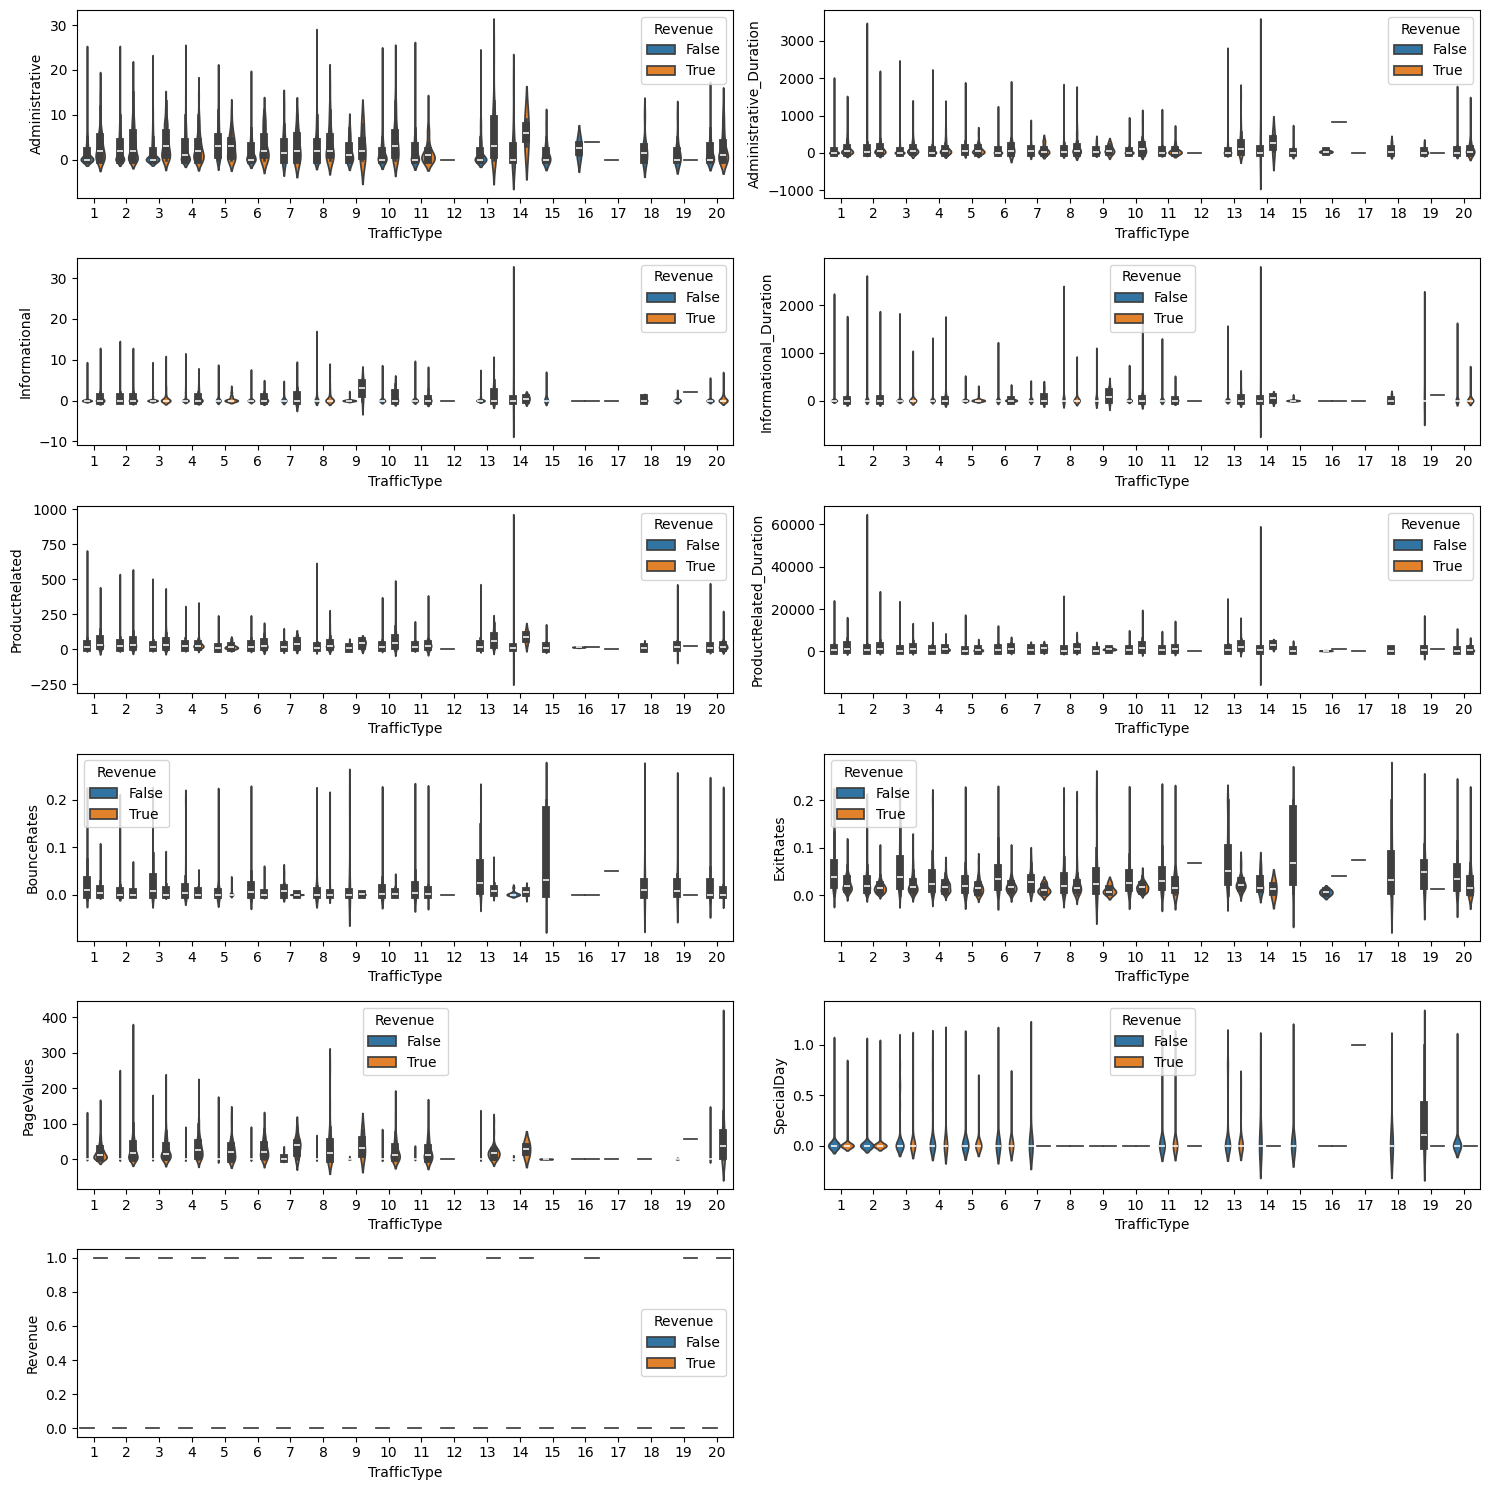

In [70]:
# Relationship between TrafficType and numerical features
fig = plt.figure(figsize=(15, 15))

for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(6, 2, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot( ax=ax, data=df, x='TrafficType', y=nums[i], hue='Revenue')  # Draw the violin plot

    plt.tight_layout()

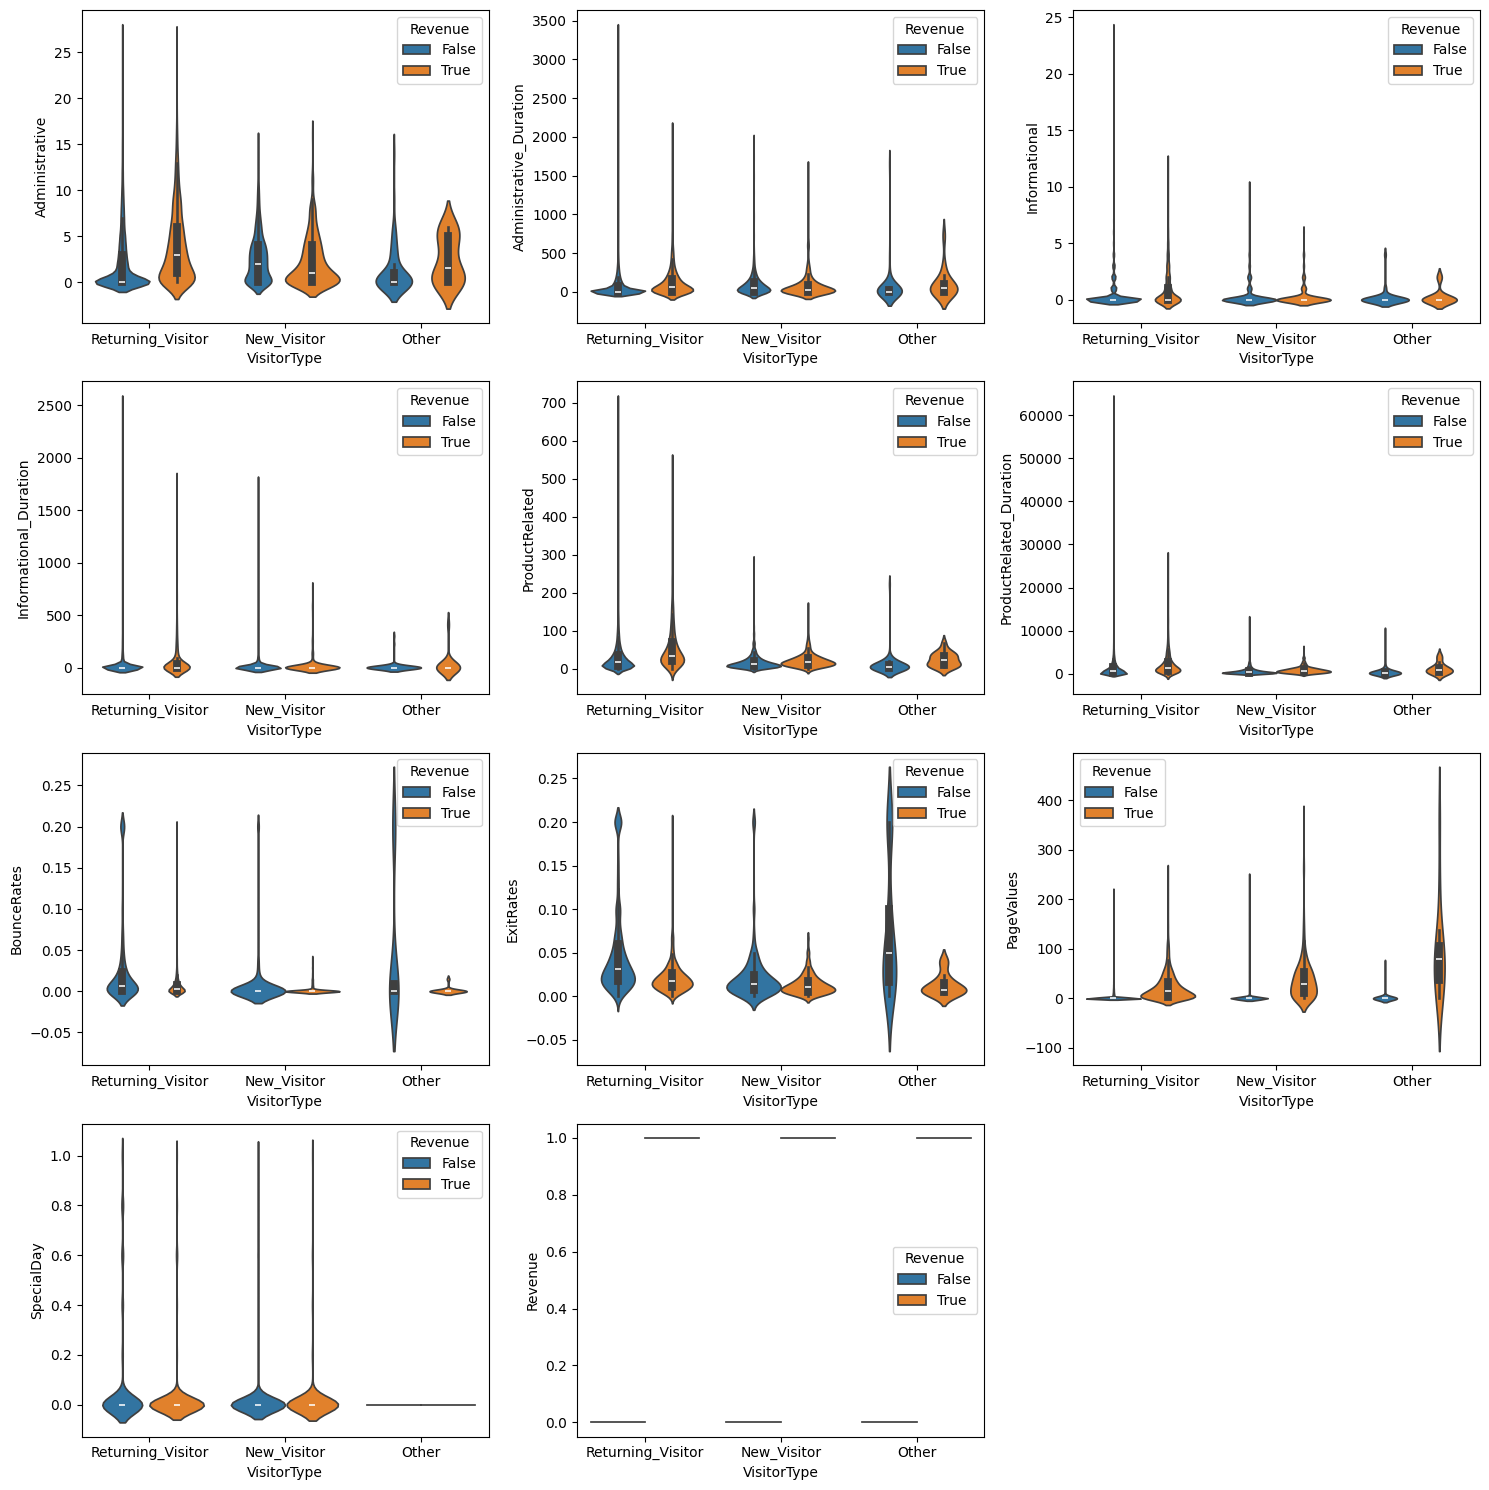

In [71]:
# Relationship between VisitorType and numerical features
fig = plt.figure(figsize=(15, 15))

for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(4, 3, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot(ax=ax, data=df, x='VisitorType',y=nums[i],hue='Revenue')  # Draw the violin plot

    plt.tight_layout()

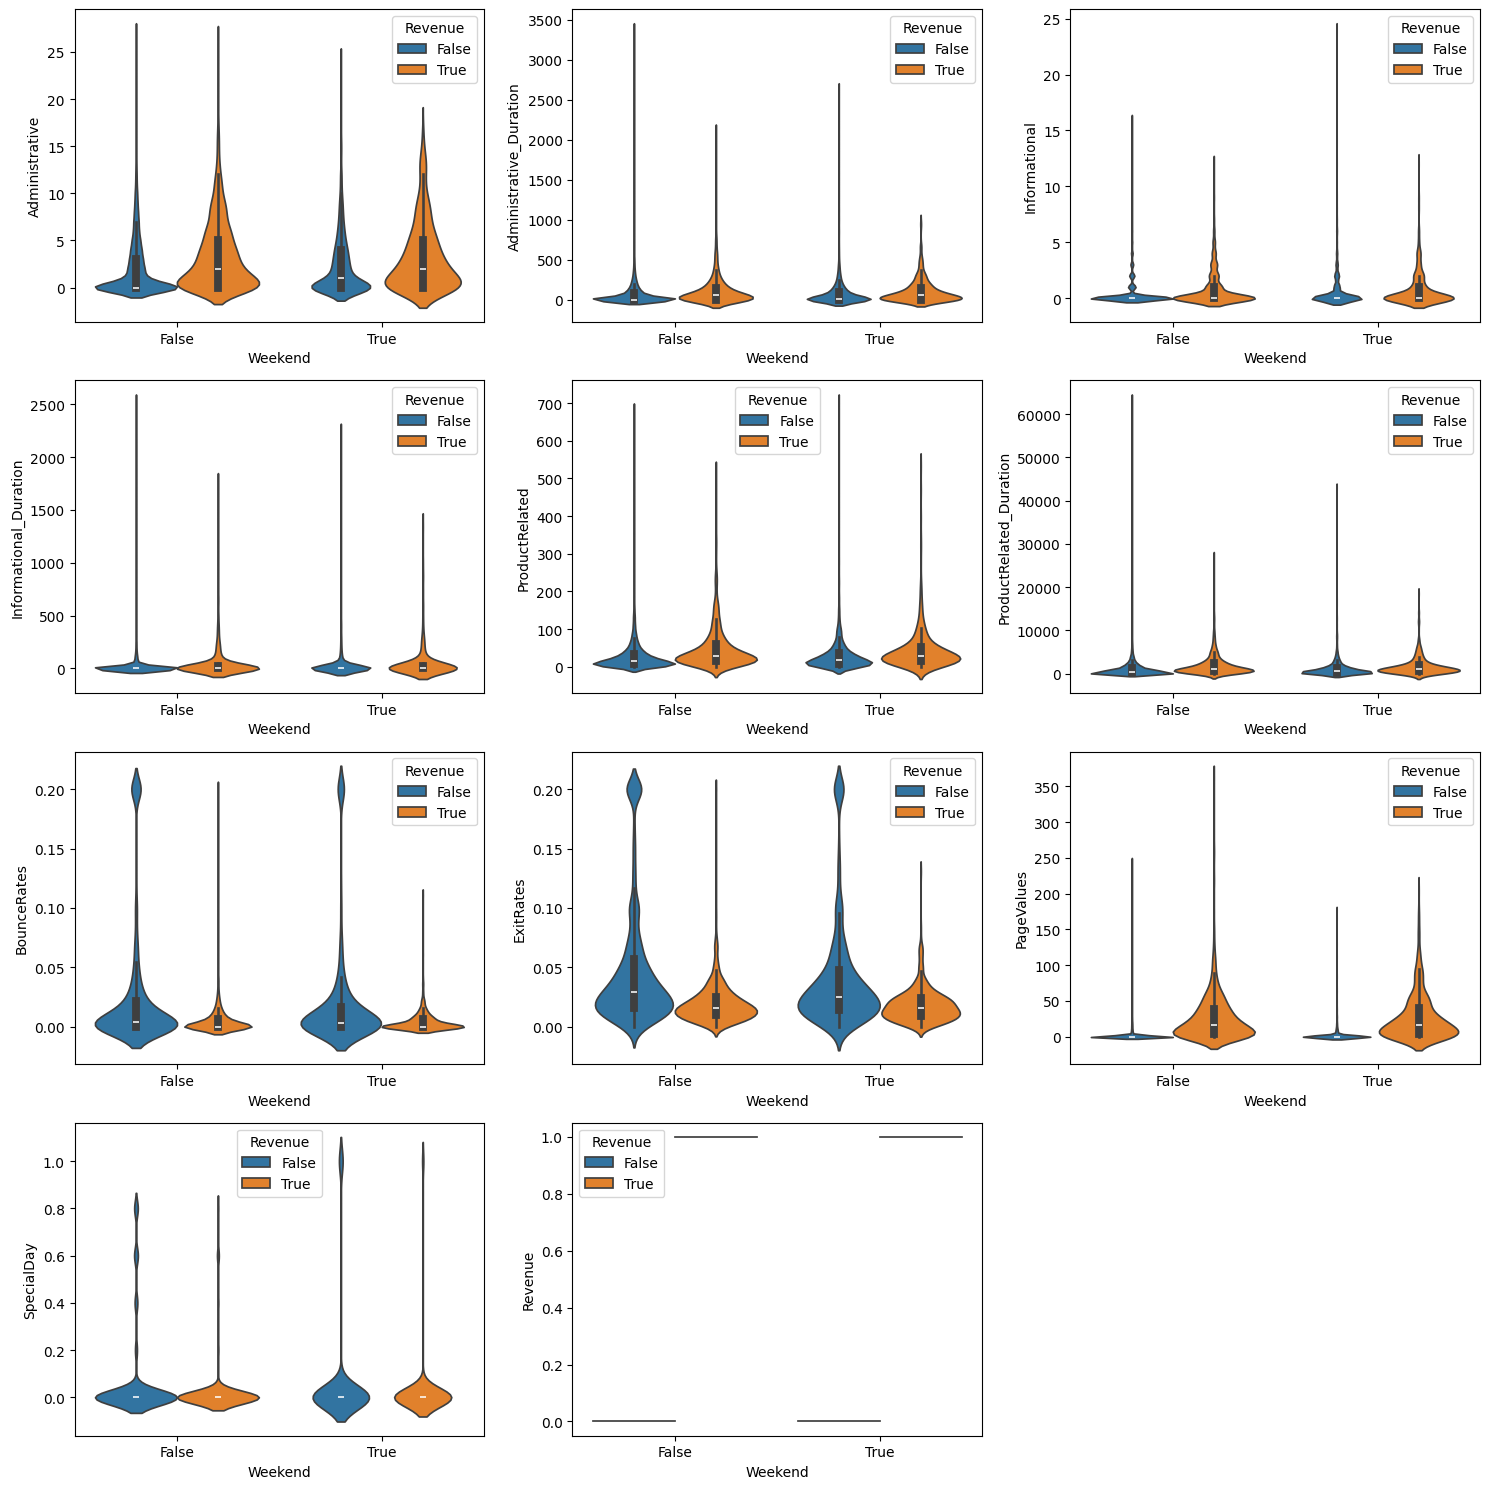

In [72]:
# Relationship between Weekend and numerical features
fig = plt.figure(figsize=(15, 15))

for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(4, 3, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot( ax=ax, data=df, x='Weekend', y=nums[i], hue='Revenue' )  # Draw the violin plot

    plt.tight_layout()

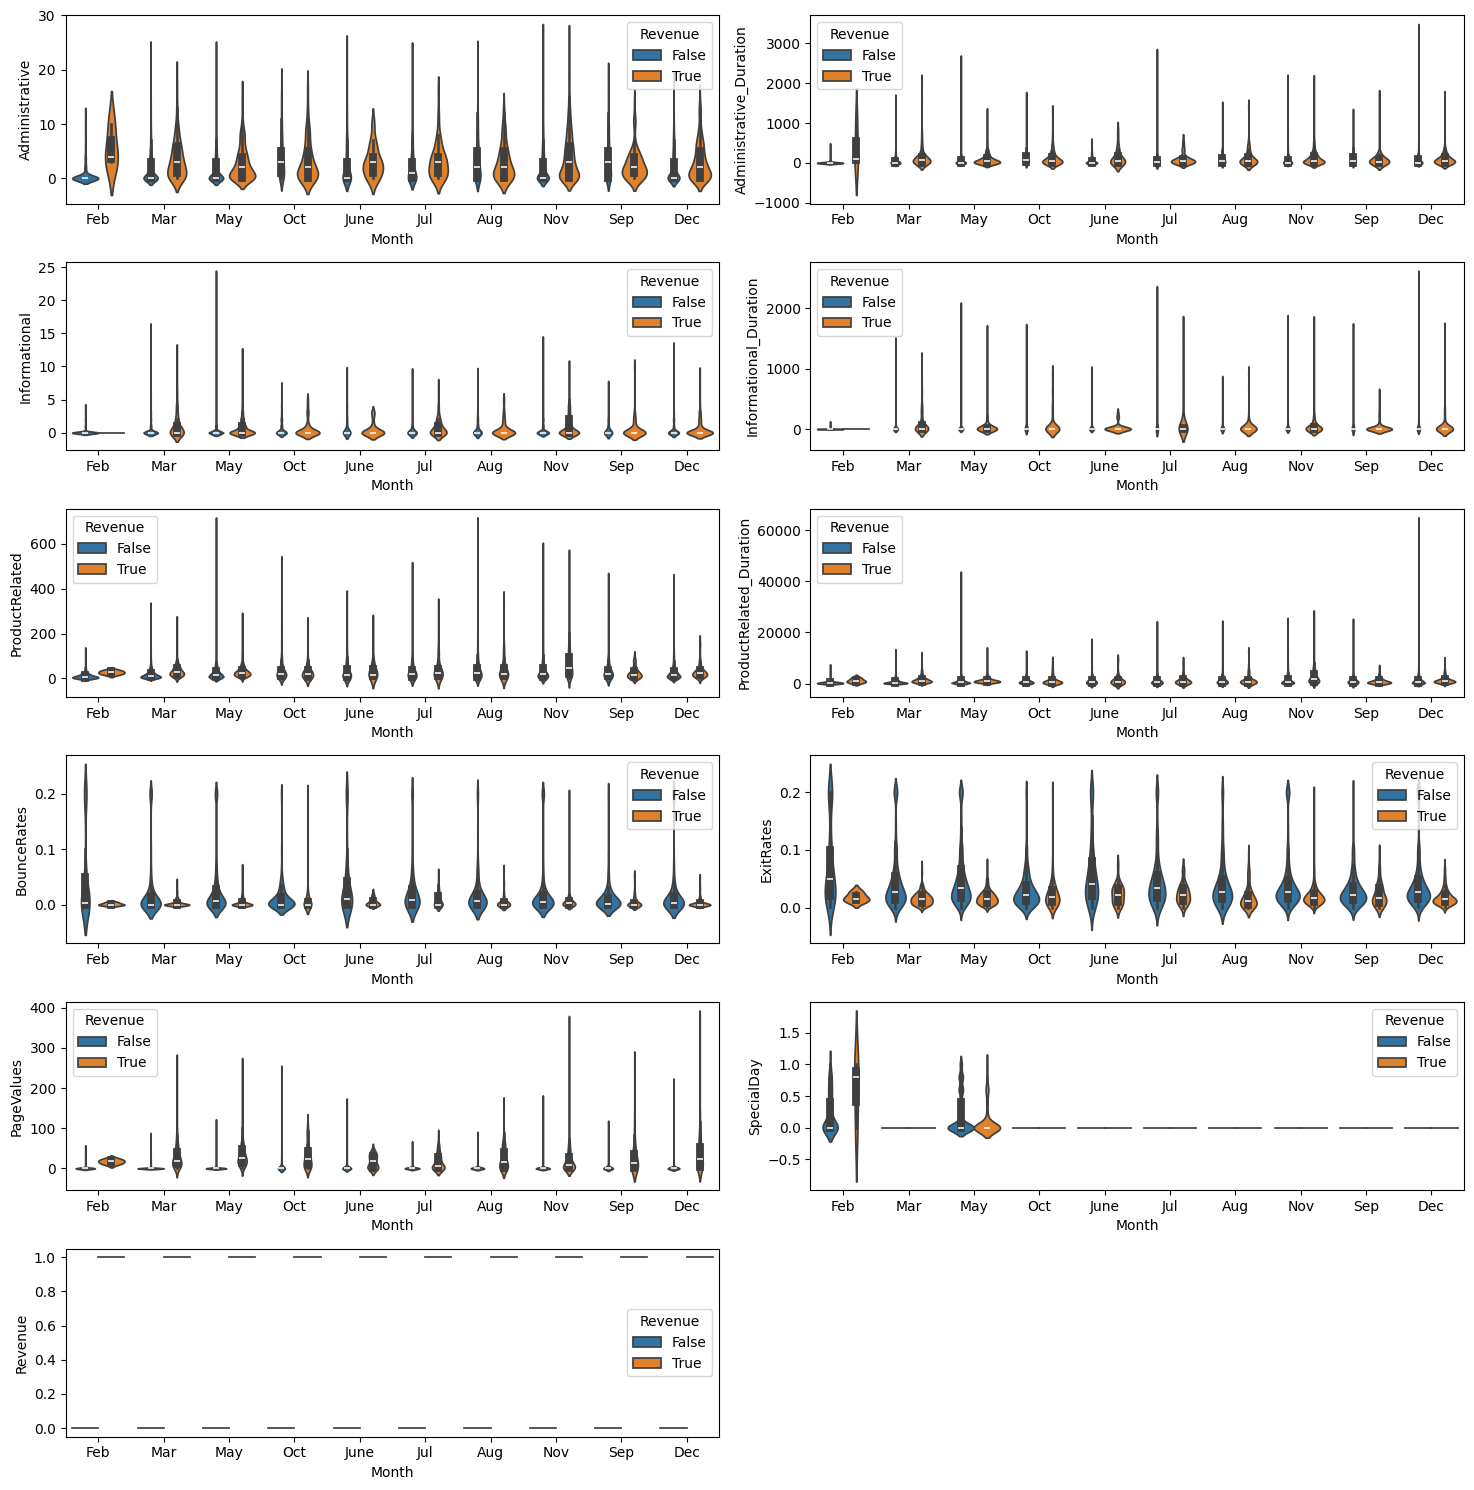

In [ ]:
# Relationship between Month and numerical features
fig = plt.figure(figsize=(15, 15))

for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(6, 2, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot( ax=ax, data=df,x='Month', y=nums[i], hue='Revenue' )  # Draw the violin plot

    plt.tight_layout()

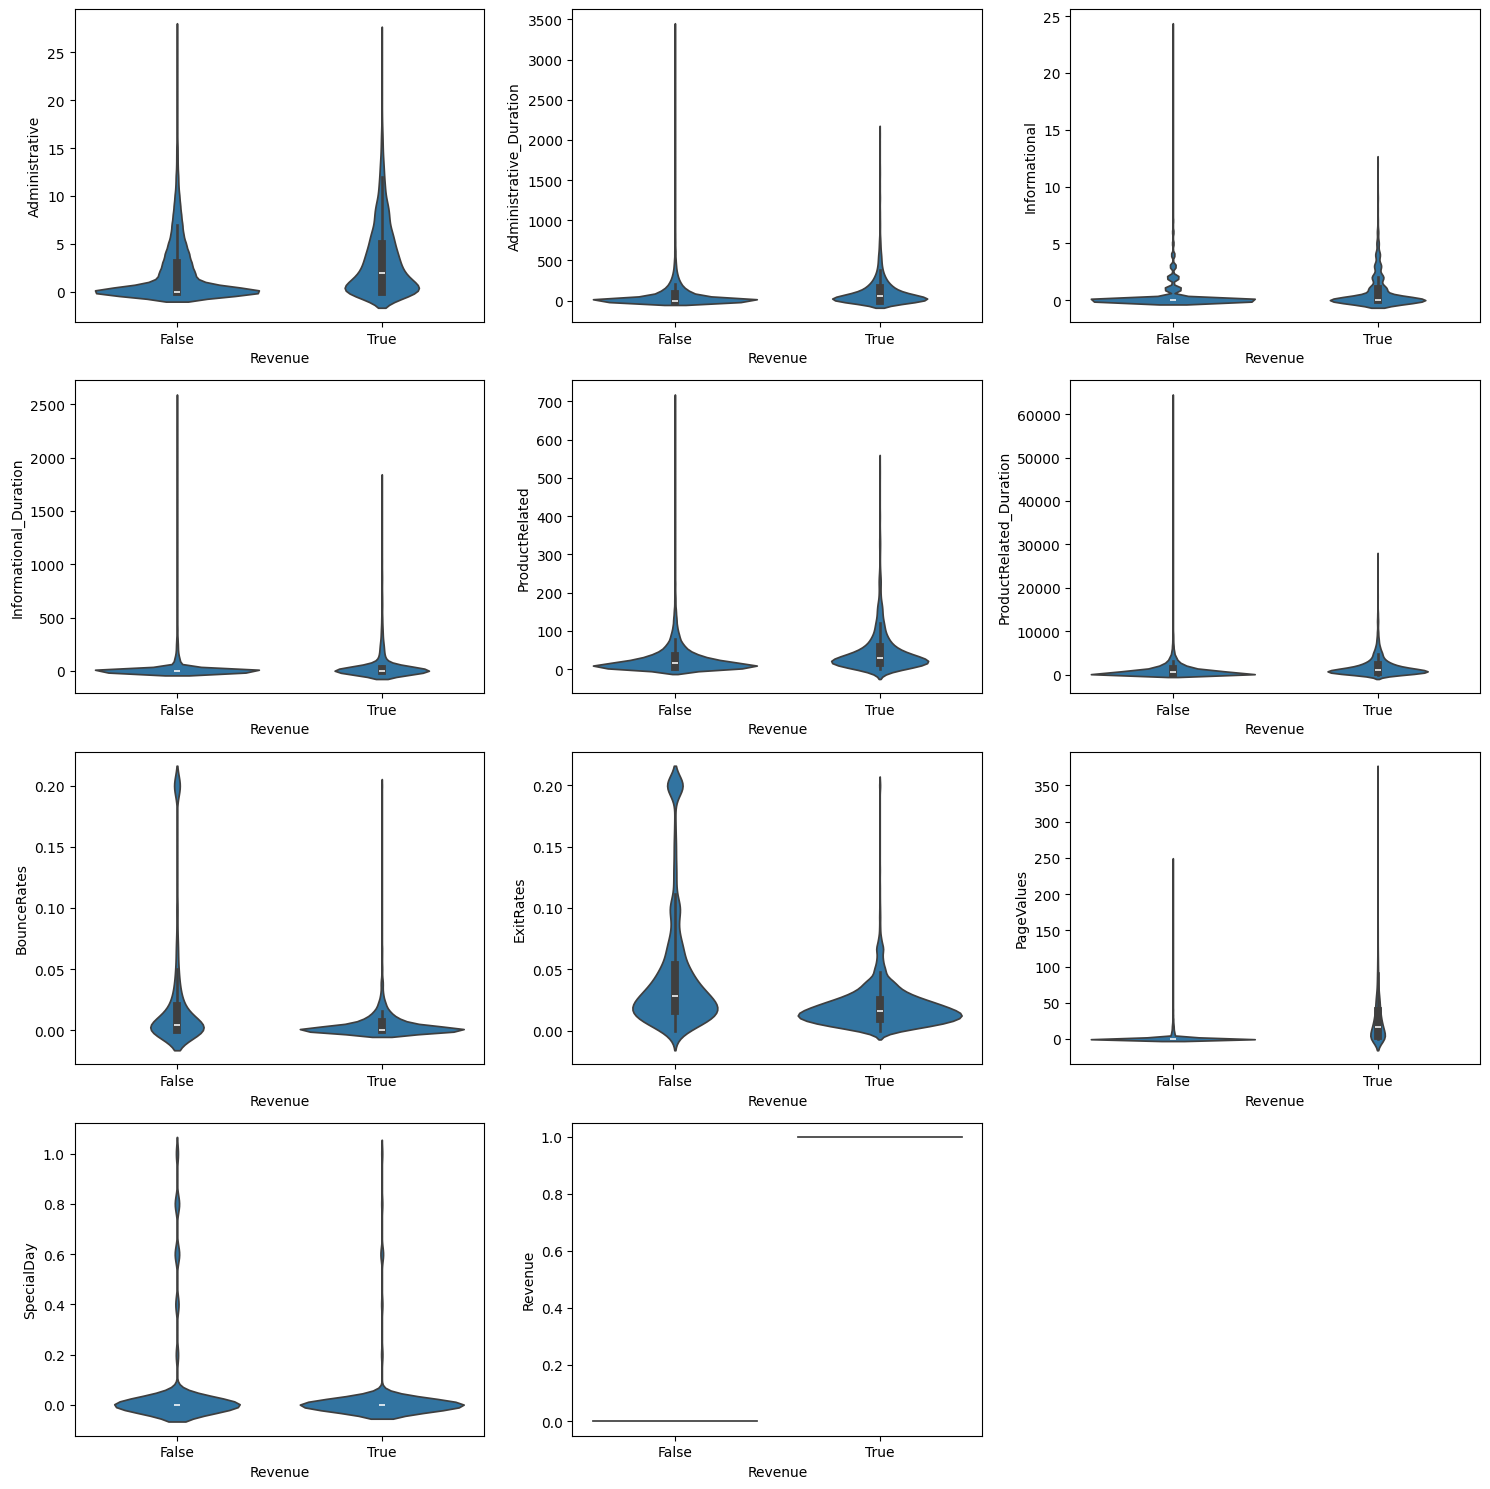

In [76]:
# Relationship between Revenue and numerical features
fig = plt.figure(figsize=(15, 15))

for i in range(0, len(nums)):  # Loop through each numerical feature
    ax = fig.add_subplot(4, 3, i + 1)  # Set the position of each violin plot in the layout
    sns.violinplot(ax=ax, data=df, x='Revenue', y=nums[i])  # Draw the violin plot

plt.tight_layout()
plt.show()

### **C ) Relationships Among Categorical Features**

In [75]:
tips_categorical = df[cats]
tips_categorical

KeyError: "['Weetond'] not in index"

In [ ]:
from scipy.stats import chi2_contingency
rows = []
for var1 in tips_categorical:
    col = []
    for var2 in tips_categorical:
        cramers = cramers_V(tips_categorical[var1], tips_categorical[var2])
        col.append(round(cramers,2))
    rows.append(col)

cramers_result = np.array(rows)
tabel_corelation_categorical = pd.DataFrame(cramers_result, columns = tips_categorical.columns, index = tips_categorical.columns)

In [ ]:
def cramers_V(var1, var2):
    crosstab = np.array(pd.crosstab(var1, var2, rownames = None, colnames = None))
    stat = chi2_contingency(crosstab)[0]
    obs = np.sum(crosstab)
    mini = min(crosstab.shape)-1
    return (np.sqrt(stat/(obs*mini)))

In [ ]:
tabel_corelation_categorical

,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Month,Revenue
OperatingSystems,1.00,0.60,0.12,0.20,0.47,0.12,0.06,0.08
Browser,0.60,1.00,0.13,0.19,0.51,0.09,0.07,0.05
Region,0.12,0.13,1.00,0.09,0.18,0.03,0.05,0.03
TrafficType,0.20,0.19,0.09,1.00,0.39,0.15,0.20,0.17
VisitorType,0.47,0.51,0.18,0.39,1.00,0.06,0.14,0.10
Weekend,0.12,0.09,0.03,0.15,0.06,1.00,0.06,0.03
Month,0.06,0.07,0.05,0.20,0.14,0.06,1.00,0.18
Revenue,0.08,0.05,0.03,0.17,0.10,0.03,0.18,1.00


<AxesSubplot: >

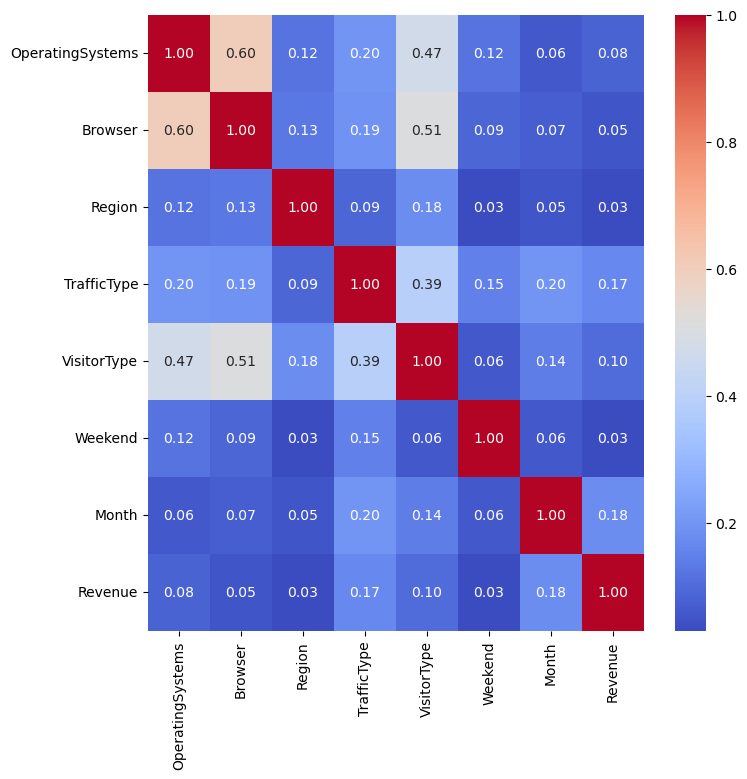

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(tabel_corelation_categorical, cmap = 'coolwarm', annot = True, fmt = '.2f')

- **Browser** and **OperatingSystems** exhibit a relatively strong correlation.
- **Browser** and **VisitorType** lso show a relatively high correlation.
- Most features have weak correlations with the target variable (Revenue), indicating that no single feature has a strong linear relationship with the purchase outcome.

# **4. Business Insight**
---

### **A ) VisitorType With Revenue**

Analyze the purchasing behavior of different visitor types based on the Revenue outcome.

([<matplotlib.patches.Wedge at 0x2206e644df0>,
 [Text(-1.0788208079242065, 0.525495636889368, 'Returning_Visitor'),
  Text(1.0671878754415025, -0.5487349437667082, 'New_Visitor'),
  Text(1.1997185885832733, -0.025986692897690122, 'Other')],
 [Text(-0.6293121379557871, 0.306539121518798, '85.57'),
  Text(0.6225262606742097, -0.32009538386391306, '13.74'),
  Text(0.6998358433402426, -0.015158904190319237, '0.69')])

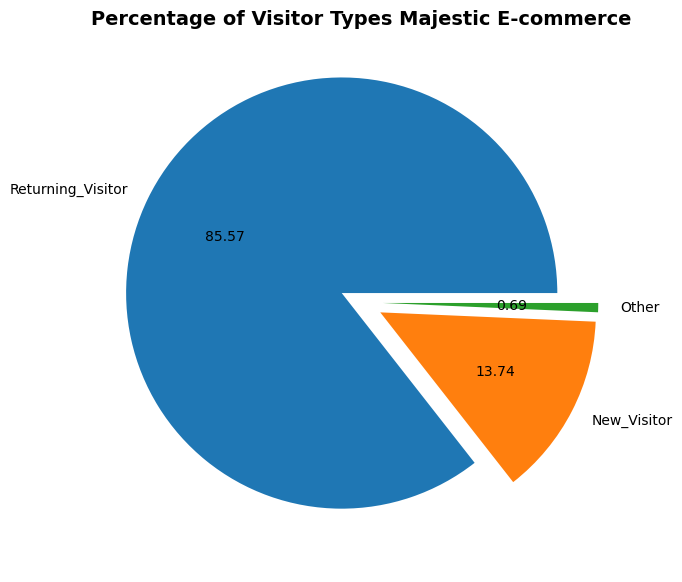

In [ ]:
# Calculate the percentage distribution of visitor types

plt.figure(figsize=(15,7))
plt.title('Percentage of Visitor Types Majestic E-commerce',fontsize=14,fontweight='bold')
plt.pie(x=df['VisitorType'].value_counts(),
        labels = ['Returning_Visitor','New_Visitor','Other'],
        autopct='%.2f',
        explode = (0.1,0.1,0.1))


In [ ]:
# Create a pivot table to analyze the relationship between VisitorType and Revenue
df_cal = df.copy()
val =['Other', 'New_Visitor', 'Returning_Visitor']
df_cal['VisitorType'] = pd.Categorical(df_cal['VisitorType'], categories = val)

v_rev = df_cal.groupby(['VisitorType', 'Revenue'])['Revenue'].count()
v_rev = v_rev.reset_index(name='count')
v_rev['percentage'] =  (100 * v_rev['count'] / v_rev.groupby('VisitorType')['count'].transform('sum')).round(2)

pvt = v_rev.pivot_table(index='VisitorType', columns='Revenue', values=['count', 'percentage'])
pvt

count       percentage       
Revenue           False  True      False   True
VisitorType                                    
Other                69    16      81.18  18.82
New_Visitor        1272   422      75.09  24.91
Returning_Visitor  9081  1470      86.07  13.93

Text(2900, 0.9, '25%')

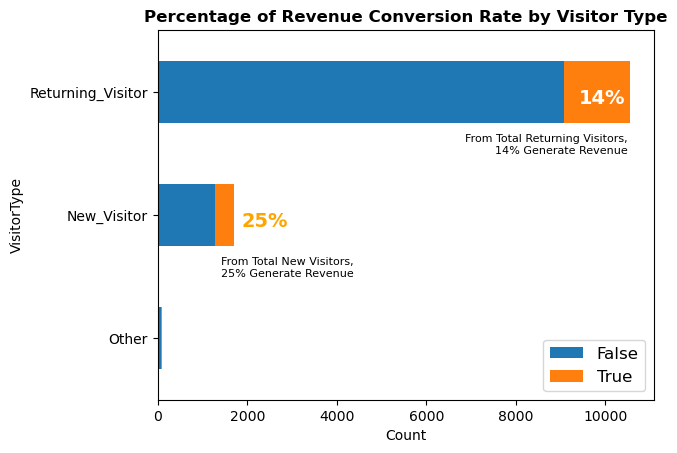

In [ ]:
pvt_count = v_rev.pivot_table(index='VisitorType', columns='Revenue', values='count')

ax = pvt_count.plot(kind='barh', stactod=True)
plt.title('Percentage of Revenue Conversion Rate by Visitor Type', fontweight='bold')
plt.xticks(rotation=360)
plt.xlabel('Count')
plt.legend(loc='lower right', fontsize=12)

plt.annotate(xy=(10500,1.5), xytext=(10500, 1.5), text='From Total Returning Visitors,\n14% Generate Revenue', fontsize=8, ha='right')
plt.annotate(xy=(10450,1.9), xytext=(10450, 1.9), text='14%', fontsize=14, ha='right', fontweight='bold', color='white')

plt.annotate(xy=(2900,0.5), xytext=(2900, 0.5), text='From Total New Visitors,\n25% Generate Revenue', fontsize=8, ha='center')
plt.annotate(xy=(2900,0.9), xytext=(2900, 0.9), text='25%', fontsize=14, ha='right', fontweight='bold', color='orange')

Over the past year, the number of new visitors has been significantly lower than the number of returning visitors. This indicates that the e-commerce platform has been successful in retaining existing customers. However, despite the high proportion of returning visitors, the overall revenue generated remains relatively low, suggesting there is still room to improve conversion among returning customers. <br>

**Business Recommendations:** 
- Offer promotions, discount vouchers, or referral codes to attract more new visitors and expand the customer base..
- Conduct further analysis of returning visitors' behavior to identify effective strategies for increasing their purchase frequency and overall revenue.
- Implement personalized marketing campaigns, loyalty programs, or targeted product recommendations to encourage repeat purchases from returning visitors.

### **B ) Visitor per Month With Revenue**

In [ ]:
df_m = df.copy()
val =['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_m['Month'] = pd.Categorical(df_cal['Month'], categories = val)

df_m = df_m.groupby(['Month', 'Revenue'])['Month'].count()
df_m = df_m.reset_index(name='count')
df_m['percentage'] =  (100 * df_m['count'] / df_m.groupby('Month')['count'].transform('sum')).round(2)

pvt = df_m.pivot_table(index='Month', columns='Revenue', values=['count', 'percentage'])
pvt

count      percentage       
Revenue False True      False   True
Month                               
Feb       181    3      98.37   1.63
Mar      1715  192      89.93  10.07
May      2999  365      89.15  10.85
June      259   29      89.93  10.07
Jul       366   66      84.72  15.28
Aug       357   76      82.45  17.55
Sep       362   86      80.80  19.20
Oct       434  115      79.05  20.95
Nov      2238  760      74.65  25.35
Dec      1511  216      87.49  12.51

Text(7.97, 2550, 'November has the highest total visitors with \nthe highest monthly revenue conversion rate, \nreaching 25%.')

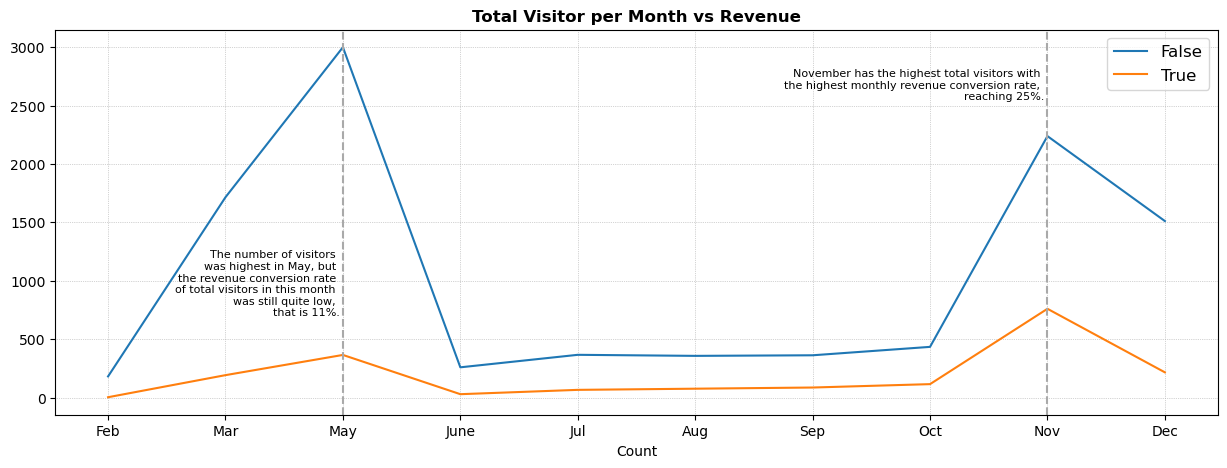

In [ ]:
pvt_count = df_m.pivot_table(index='Month', columns='Revenue', values='count')

ax = pvt_count.plot(kind='line', figsize=(15,5))
plt.title('Total Visitor per Month vs Revenue', fontweight='bold')

# plt.xticks(rotation=360)
plt.xlabel('Count')
plt.legend(loc='lower right', fontsize=12)
plt.grid(color='darkgray', linestyle=':', linewidth=0.5)
plt.legend(loc='upper right', fontsize=12)

ax.set_xticks(np.arange(len(pvt_count))) #Show ticks for each country
ax.set_xticklabels(val) 

plt.axvline(x=2, color='darkgrey', ls='--', lw=1.5)
plt.axvline(x=8, color='darkgrey', ls='--', lw=1.5)

plt.text(1.97, 700, s='The number of visitors \nwas highest in May, but \nthe revenue conversion rate \nof total visitors in this month \nwas still quite low, \nthat is 11%.', 
         fontsize=8, ha = 'right')
plt.text(7.97, 2550, s='November has the highest total visitors with \nthe highest monthly revenue conversion rate, \nreaching 25%.', 
         fontsize=8, ha = 'right')

Website traffic peaked in May, followed by November. However, despite having the highest number of visitors, May recorded a relatively low revenue conversion rate of only 11%.

In contrast, November not only attracted a large number of visitors but also achieved the highest monthly revenue conversion rate, reaching approximately 25%. This suggests that visitors during November were more likely to complete a purchase than those in any other month.<br>

**Business Recommendations :**
- These insights can help the marketing team plan and optimize campaigns during months with high website traffic and strong revenue conversion rates, maximizing the return on marketing investments.

- From June to October, the revenue conversion rate ranges between approximately 15% and 20%, which is relatively low compared to the best-performing months. Additional marketing initiatives, such as promotional campaigns, seasonal discounts, or targeted advertising, should be implemented to increase website traffic during these months, with the goal of improving both conversions and overall revenue.


### **C ) Region With Revenue**

In [ ]:
reg = df.copy()
reg = reg.groupby(['Region', 'Revenue'])['Region'].count()
reg = reg.reset_index(name='count')
reg['percentage'] =  (100 * reg['count'] / reg.groupby('Region')['count'].transform('sum')).round(2)

pvt = reg.pivot_table(index='Region', columns='Revenue', values=['count', 'percentage'])
pvt

count      percentage       
Revenue False True      False   True
Region                              
1        4009  771      83.87  16.13
2         948  188      83.45  16.55
3        2054  349      85.48  14.52
4        1007  175      85.19  14.81
5         266   52      83.65  16.35
6         693  112      86.09  13.91
7         642  119      84.36  15.64
8         378   56      87.10  12.90
9         425   86      83.17  16.83

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9')])

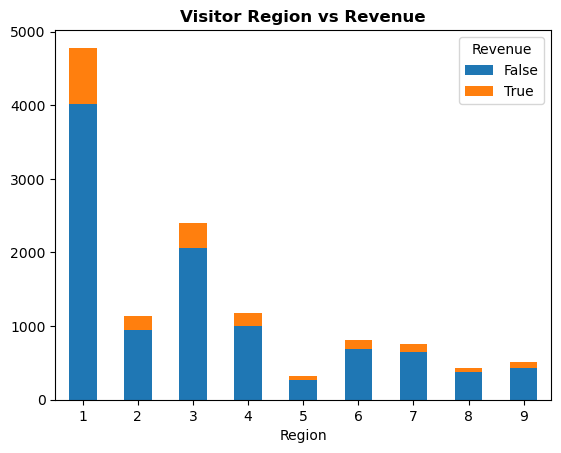

In [ ]:
pvt_count = reg.pivot_table(index='Region', columns='Revenue', values='count')

ax = pvt_count.plot(kind='bar', stactod=True)
plt.title('Visitor Region vs Revenue', fontweight='bold')
plt.xticks(rotation=360)

Most website visitors came from Region 1, which also exhibited a relatively high revenue conversion rate.<br>

**Business Recommendations:** 
- Increase marketing and promotional efforts in underperforming regions to drive customer engagement and improve revenue. At the same time, continue optimizing promotional campaigns in Region 1 to maximize its already strong conversion performance and further increase revenue. ✅

### **D ) Weekend Vs Revenue**

In [ ]:
w = df.copy()
w = w.groupby(['Weetond', 'Revenue'])['Region'].count()
w = w.reset_index(name='count')
w['percentage'] =  (100 * w['count'] / w.groupby('Weekend')['count'].transform('sum')).round(2)

pvt = w.pivot_table(index='Weekend', columns='Revenue', values=['count', 'percentage'])
pvt

count       percentage       
Revenue False  True      False   True
Weekend                              
False    8053  1409      85.11  14.89
True     2369   499      82.60  17.40

(array([0, 1]), [Text(0, 0, 'False'), Text(1, 0, 'True')])

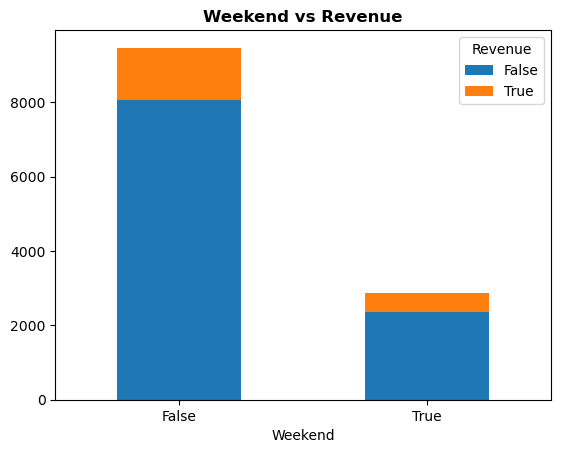

In [ ]:
pvt_count = w.pivot_table(index='Weekend', columns='Revenue', values='count')

ax = pvt_count.plot(kind='bar', stactod=True)
plt.title('Weekend vs Revenue', fontweight='bold')
plt.xticks(rotation=360)

(array([  0.,  20.,  40.,  60.,  80., 100., 120.]),
 [Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120')])

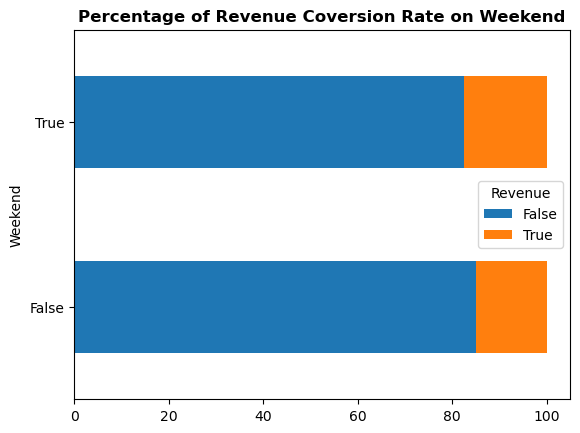

In [ ]:
pvt_count = w.pivot_table(index='Weetond', columns='Revenue', values='percentage')

ax = pvt_count.plot(kind='barh', stactod=True)
plt.title('Percentage of Revenue Coversion Rate on Weetond', fontweight='bold')
plt.xticks(rotation=360)

The revenue conversion rates on weekends and weekdays are not significantly different. However, weekdays show a slightly higher conversion rate. This difference may be attributed to the greater number of weekdays compared to weekends or because visitors are more likely to browse the e-commerce website during weekdays.<br>

**Business Recommendation:**

- Schedule marketing campaigns and promotional activities during peak hours or time periods when users are most likely to visit the e-commerce website, particularly on weekdays, to maximize traffic and conversion opportunities.

